# 주문 금액과 고객 만족 — 가설 4

검증할 가설: **주문 금액이 높을수록 고객 만족도가 낮다. 그 차이가 무엇에서 오는지를 금액이 높아진 경로와 배송, 카테고리로 나눠 확인한다.**

앞의 가설들은 배송 약속과 판매자를 개입의 대상으로 보았다.
이 가설은 주문이 원래 가진 요소 중 모든 주문에 값이 있고 계산이 단순한 주문 금액이 만족을 가르는지를 묻는다.

주문 금액이 높아지는 길은 둘이다. 비싼 상품을 사거나, 여러 개를 산다.
두 길은 만족에 다르게 작용할 수 있다. 여러 개를 산 주문은 같은 상품을 여러 개 산 것일 수도 있고,
다른 상품이 섞인 것일 수도 있다. 섞인 정도는 한 카테고리 안인지 카테고리가 여럿인지로 나눠 본다.

확인하는 것은 넷.

1. 주문 금액이 높을수록 리뷰 점수가 낮은가
2. 그 차이 중 얼마가 약속 위반과 배송 소요일에서 오는가
3. 그 차이 중 얼마가 카테고리의 가격대에서 오는가
4. 같은 금액대에서 상품 개수와 상품 구성에 따라 점수가 어떻게 달라지는가

각 요인이 설명하는 몫에 따라 대상이 정해진다. 배송에서 오는 몫은 06 · 07 의 예상 도착일 처방으로,
카테고리에서 오는 몫은 카테고리로 돌아간다. 상품 개수와 상품 구성에서 오는 몫은 점수를 견줄 때 함께 맞추고,
어느 쪽으로도 설명되지 않는 몫은 금액이 높은 주문 자체가 대상이 된다.

주문 금액은 03 에서 정한 대로 상품 금액 + 운임, 주문 단위로 `SUM(price) + SUM(freight_value)`.
결제액은 할부 개월 수에 비례해 불어나는 값이라 쓰지 않는다.

고객 만족도는 05 에서 정한 대로 리뷰 점수(1 ~ 5)로 측정. 공용 표본과 축약 규칙도 05 를 따르며
뷰 `order_review` 를 그대로 사용.

**확인 항목**

- 판정 기준 — 무엇이 나오면 성립하고 무엇이 나오면 불성립인가 (1)
- 표본 — 05 공용 표본에 더 걸 조건과 그때 빠지는 규모, 한 주문의 카테고리 구성 (2)
- 전용 지표 — 주문 금액의 분포와 금액 분위, 상품 금액과 운임의 관계 (3)
- 조건 1 — 주문 금액이 높을수록 리뷰 점수가 낮은가 (4)
- 조건 2 — 그 차이 중 배송에서 오는 몫, 운임은 배송에 어떻게 걸리는가 (5)
- 조건 3 — 그 차이 중 카테고리 구성에서 오는 몫 (6)
- 조건 4 — 같은 금액대에서 상품 개수와 상품 구성에 따라 점수가 어떻게 달라지는가 (7)

## 0. 연결

05 가 만든 뷰 `order_review` 를 사용하므로 05 실행 이후의 상태가 전제.
처음부터 다시 돌릴 때는 02 로 원본을 복원한 뒤 03 · 04 · 05 순서로 실행.

In [1]:
import duckdb

con = duckdb.connect('../olist.duckdb')
con.execute("SET enable_progress_bar = false");

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi'] = 110
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.25
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

BLUE, SAND, RED, GRAY = '#3C6E9F', '#D9A05B', '#B3524B', '#8A8F94'

## 1. 판정 기준

주문 금액은 값 그대로가 아니라 주문 수가 같은 10 개 분위로 나눠 비교한다.
분위마다 주문 수가 같아 한쪽 금액대에 표본이 몰리지 않는다. 금액이 어떻게 흩어져 있는지는 3 에서 확인한다.

양 끝 두 분위만 견주면 가운데 여덟 분위가 빠지므로 **기울기**를 함께 쓴다.
주문 하나를 점으로 놓고, 그 주문이 속한 분위 번호(1 ~ 10)에 리뷰 점수를 회귀한 값이다.

- 가로축은 금액이 아니라 **분위 번호**다. 분위는 주문 수가 같게 나눈 것이므로 한 칸은 금액 순위로 10 % 를 뜻하고,
  한 칸이 담는 금액 폭은 분위마다 다르다. 따라서 기울기는 `금액 1 R$ 당 점수 변화`가 아니라
  `금액 순위에서 10 % 올라갈 때의 점수 변화`다
- 분위를 따라 곧게 움직인다고 보고 직선을 맞춘 값이라, 한쪽 끝에서 급해지는 모양은 이 한 수치에 담기지 않는다.
  그런 모양은 분위별 표와 그림에서 본다
- 같은 방식으로 10 분위를 나눈 것끼리만 견준다. 나누는 범위나 등분 수가 다르면 한 칸의 뜻이 달라진다

**조건 1 — 주문 금액이 높을수록 리뷰 점수가 낮은가, 높은가.**

- 낮아진다 — 최상위 분위의 평균 점수가 최하위 분위보다 낮고 기울기가 음수이며, 둘의 95 % 구간이 0 을 포함하지 않는다.
  1 ~ 2 점 비율은 반대로 오른다
- 높아진다 — 같은 값들의 부호가 반대이고, 구간이 0 을 포함하지 않는다
- 방향 없음 — 차이나 기울기의 구간이 0 을 포함한다

가설은 낮아진다는 쪽이다.

**조건 2 — 그 차이 중 배송에서 오는 몫은 얼마인가.**

금액 분위별 약속 위반율을 보고, 약속을 지킨 주문끼리 분위를 다시 비교한다.
약속을 지킨 주문 안에서도 금액이 높은 분위일수록 소요일이 길 수 있으므로 소요일의 영향을 제외하고 한 번 더 본다.
운임은 배송 거리와 무게를 반영해 매겨지므로 운임으로 나눈 분위도 함께 본다.

- 기울기를 약속 위반 구성 · 소요일 구성 · 남는 몫으로 나눠 배송의 몫을 적는다
- 약속 준수 여부와 소요일의 영향을 제외해도 기울기의 95 % 구간이 0 을 포함하지 않으면 배송 밖의 몫이 남는다

**조건 3 — 그 차이 중 카테고리 구성에서 오는 몫은 얼마인가.**

카테고리 구성에서 온다면 카테고리의 가격대와 그 카테고리의 점수 사이에 관계가 있어야 하므로 먼저 그것을 본다.
이어서 카테고리 하나로만 이루어진 주문을 같은 카테고리 안에서 금액 10 분위로 나눠 비교한다.
같은 주문을 조건 1 과 같은 방식으로 다시 10 분위로 나눈 값과 견주면 카테고리 가격대가 설명하는 몫이 나온다.

- 같은 주문에서 전체 금액 분위의 기울기와 카테고리 안 분위의 기울기를 견줘, 줄어든 만큼을 카테고리의 몫으로 적는다
- 카테고리 안 분위의 기울기가 0 을 포함하지 않으면 카테고리 밖의 몫이 남는다

**조건 4 — 같은 금액대에서 상품 개수와 상품 구성에 따라 점수가 어떻게 달라지는가.**

4 의 금액 분위를 그대로 두고 상품 1 개와 2 개 이상으로 나눈다. 분위를 다시 나누지 않는다.

- 상품 개수 — 같은 분위에서 두 무리의 평균 점수를 견주고, 4 의 기울기를 상품 개수 구성의 몫과 상품 개수를 고정하고 남는 몫으로 나눈다
- 상품 구성 — 상품 2 개 이상인 주문을 같은 상품 / 다른 상품 · 한 카테고리 / 카테고리 2 개 이상으로 나누고,
  판매자 수를 고정해 견준다. 구간이 겹치면 차이를 확인하지 못한 것으로 적고, 표본이 작은 칸은 가를 수 있는 차이의 크기를 함께 적는다

조건 2 ~ 4 의 몫은 각각 4 의 전체 기울기를 기준으로 구하므로 서로 더하지 않는다.
어느 쪽으로도 설명되지 않고 남는 몫은 금액이 높은 주문 자체가 대상이 된다.

## 2. 표본 — 공용 표본에 더 걸 조건

05 의 공용 표본 98,330 건(2017-01 ~ 2018-08 구매 · 리뷰 있음 · 주문 하나에 점수 하나)에 이 가설에만 필요한 조건을 더한다.

- **배송 완료** — 조건 2 가 약속 준수 여부를 쓰므로 배송을 겪고 완료 시각이 남은 주문이어야 함
- **상품 기록 있음** — 주문 금액은 `order_items` 에서 계산하므로 상품이 없는 주문에는 값이 없음

07 과 달리 판매자가 여럿인 주문도 남긴다. 주문 금액은 판매자와 무관하게 주문 단위로 계산된다.

조건을 누적해 걸며 남는 행을 집계. 단계마다 줄어드는 폭이 그 조건에서 빠지는 주문의 규모.

In [3]:
con.execute("""
SELECT '1. 공용 표본' AS step,
       COUNT(*)      AS rows
FROM order_review

UNION ALL
SELECT '2. + 배송 완료', COUNT(*)
FROM order_review
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL

UNION ALL
SELECT '3. + 상품 기록 있음', COUNT(*)
FROM order_review AS o
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND EXISTS (SELECT 1 FROM order_items AS i WHERE i.order_id = o.order_id)

ORDER BY step
""").df()

,step,rows
0,1. 공용 표본,98330
1,2. + 배송 완료,95560
2,3. + 상품 기록 있음,95560


공용 표본 98,330 건에서 95,560 건이 남는다. 전체의 97.18 %.

- **배송 미완료 2,762 건 · 완료 시각 없음 8 건** — 배송을 겪지 않았거나 완료 시각이 없어 약속 준수를 물을 수 없는 주문
- **상품 기록 없음 0 건** — 상품이 없는 주문은 배송된 것이 없어 앞 조건에서 이미 전부 빠졌다

한 주문의 카테고리 구성을 확인한다. 카테고리가 여럿이거나 카테고리가 등록되지 않은 상품이 끼면
주문을 카테고리 하나로 묶을 수 없다.

- `category_type` — 등록된 카테고리 하나 / 카테고리 여럿 / 미등록 상품 포함. 미등록 상품이 끼면 카테고리 수와 관계없이 마지막으로 센다
- `orders` · `pct` — 주문 수와 비율

In [4]:
con.execute("""
WITH base AS (
    SELECT order_id
    FROM order_review
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
),
per_order AS (
    SELECT b.order_id,
           COUNT(DISTINCT p.product_category_name)           AS categories,
           COUNT(*) FILTER (p.product_category_name IS NULL) AS unregistered
    FROM base        AS b
    JOIN order_items AS i ON i.order_id   = b.order_id
    JOIN products    AS p ON p.product_id = i.product_id
    GROUP BY b.order_id
)
SELECT CASE WHEN unregistered > 0 THEN '3. 미등록 상품 포함'
            WHEN categories > 1   THEN '2. 카테고리 여럿'
            ELSE                       '1. 등록된 카테고리 하나' END AS category_type,
       COUNT(*)                                                 AS orders,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)       AS pct
FROM per_order
GROUP BY category_type
ORDER BY category_type
""").df()

,category_type,orders,pct
0,1. 등록된 카테고리 하나,93466,97.81
1,2. 카테고리 여럿,714,0.75
2,3. 미등록 상품 포함,1380,1.44


모든 상품이 등록된 한 카테고리에 속하는 주문은 93,466 건으로 97.81 %.
나머지 2,094 건 중 카테고리가 여럿인 주문이 714 건(0.75 %), 카테고리가 등록되지 않은 상품이 낀 주문이 1,380 건(1.44 %) 이다.

## 3. 전용 지표

2 의 조건을 적용한 결과를 뷰 `amount_review` 로 고정한다. 주문 하나에 한 행이며 05 의 점수와 약속 대비 값을 함께 담는다.

- `items` · `products` — 상품 개수와 서로 다른 상품 종류 수
- `price_sum` · `freight_sum` · `order_amount` — 상품 금액, 운임, 주문 금액(둘의 합)
- `category` — 모든 상품이 등록된 한 카테고리에 속하면 그 카테고리의 영문명, 아니면 빈 값. 번역이 없는 카테고리는 원문
- `amount_decile` — 주문 금액 10 분위. 1 이 가장 낮다. 같은 금액이 분위 경계에 걸리면 `order_id` 순으로 나눈다

In [5]:
con.execute("""
CREATE OR REPLACE VIEW amount_review AS
WITH item AS (
    SELECT i.order_id,
           COUNT(*)                                          AS items,
           COUNT(DISTINCT i.product_id)                      AS products,
           SUM(i.price)                                      AS price_sum,
           SUM(i.freight_value)                              AS freight_sum,
           COUNT(DISTINCT p.product_category_name)           AS categories,
           COUNT(*) FILTER (p.product_category_name IS NULL) AS unregistered,
           MIN(COALESCE(t.product_category_name_english,
                        p.product_category_name))            AS category_name
    FROM order_items AS i
    JOIN products    AS p ON p.product_id = i.product_id
    LEFT JOIN product_category_name_translation AS t
           ON t.product_category_name = p.product_category_name
    GROUP BY i.order_id
),
base AS (
    SELECT o.order_id,
           o.customer_state,
           o.order_purchase_timestamp,
           o.delivery_days,
           o.days_vs_promise,
           o.review_score,
           it.items,
           it.products,
           it.price_sum,
           it.freight_sum,
           it.price_sum + it.freight_sum AS order_amount,
           CASE WHEN it.categories = 1 AND it.unregistered = 0
                THEN it.category_name END AS category
    FROM order_review AS o
    JOIN item         AS it ON it.order_id = o.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
)
SELECT *,
       NTILE(10) OVER (ORDER BY order_amount, order_id) AS amount_decile
FROM base
""")

con.execute("""
SELECT COUNT(*)                           AS rows,
       COUNT(DISTINCT order_id)           AS orders,
       COUNT(category)                    AS with_category,
       COUNT(*) - COUNT(category)         AS without_category,
       COUNT(*) FILTER (order_amount = 0) AS zero_amount,
       ROUND(MIN(order_amount), 2)        AS min_amount,
       ROUND(MAX(order_amount), 2)        AS max_amount
FROM amount_review
""").df()

,rows,orders,with_category,without_category,zero_amount,min_amount,max_amount
0,95560,95560,93466,2094,0,9.59,13664.08


뷰의 행 수와 주문 수가 95,560 으로 같아 주문 하나에 한 행. 카테고리가 붙은 주문 93,466 건과 빈 값 2,094 건은
위 카테고리 구성의 집계와 같다. 주문 금액이 0 인 주문은 없고 최소 9.59, 최대 13,664.08.

주문 금액의 분포. 평균과 분위수, 주문 금액에서 운임이 차지하는 비율의 중앙값.

In [6]:
con.execute("""
SELECT ROUND(AVG(order_amount), 2)                          AS mean,
       ROUND(quantile_cont(order_amount, 0.10), 2)          AS p10,
       ROUND(quantile_cont(order_amount, 0.25), 2)          AS p25,
       ROUND(quantile_cont(order_amount, 0.50), 2)          AS p50,
       ROUND(quantile_cont(order_amount, 0.75), 2)          AS p75,
       ROUND(quantile_cont(order_amount, 0.90), 2)          AS p90,
       ROUND(quantile_cont(order_amount, 0.99), 2)          AS p99,
       ROUND(MAX(order_amount), 2)                          AS max,
       ROUND(100.0 * MEDIAN(freight_sum / order_amount), 2) AS median_freight_pct
FROM amount_review
""").df()

,mean,p10,p25,p50,p75,p90,p99,max,median_freight_pct
0,159.52,39.48,61.8,105.24,176.15,305.51,1048.6,13664.08,18.33


주문 금액의 중앙값은 105.24, 평균은 159.52 로 평균이 중앙값의 1.5 배다.
상위 10 % 가 305.51, 상위 1 % 가 1,048.60 을 넘고 최대는 13,664.08 로 높은 쪽 꼬리가 길다.
값 그대로 구간을 나누면 높은 금액 구간에 주문이 거의 남지 않으므로 1 에서 정한 대로 주문 수가 같은 분위로 나눈다.

주문 금액에서 운임이 차지하는 비율의 중앙값은 18.33 %.

주문 금액은 상품 금액과 운임의 합이므로 둘이 같이 움직이는지 본다.
금액 분위마다 상품 금액과 운임의 중앙값, 주문 금액에서 운임이 차지하는 비율의 중앙값을 구한다.

- `median_price` · `median_freight` — 상품 금액과 운임의 중앙값
- `median_freight_pct` — 주문 금액에서 운임이 차지하는 비율의 중앙값

In [7]:
con.execute("""
SELECT LPAD(CAST(amount_decile AS VARCHAR), 2, '0')         AS decile,
       COUNT(*)                                             AS orders,
       ROUND(MEDIAN(price_sum), 2)                          AS median_price,
       ROUND(MEDIAN(freight_sum), 2)                        AS median_freight,
       ROUND(100.0 * MEDIAN(freight_sum / order_amount), 2) AS median_freight_pct
FROM amount_review
GROUP BY amount_decile
ORDER BY decile
""").df()

,decile,orders,median_price,median_freight,median_freight_pct
0,01,9556,19.90,11.85,38.92
1,02,9556,31.90,15.10,31.65
2,03,9556,47.65,15.10,24.73
3,04,9556,59.90,16.11,21.18
4,05,9556,78.45,16.69,17.87
5,06,9556,99.00,17.88,15.31
6,07,9556,119.90,18.94,13.63
7,08,9556,149.99,21.22,11.96
8,09,9556,204.00,24.19,10.33
9,10,9556,399.00,32.82,6.44


금액이 높은 주문은 운임도 높다. 금액 1 분위에서 상품 금액 중앙값 19.90 · 운임 11.85 이던 것이
10 분위에서 399.00 · 32.82 이 된다. 다만 오르는 폭이 달라 상품 금액이 20 배가 되는 동안 운임은 2.8 배가 된다.

그래서 주문 금액에서 운임이 차지하는 비율은 반대로 내려간다. 1 분위 38.92 % 에서 10 분위 6.44 % 로,
금액이 낮은 주문일수록 운임이 차지하는 몫이 크다.

상품 금액과 운임의 상관계수. 분위 안에서는 주문 금액이 거의 고정되어 상품 금액이 크면 운임이 작아지므로
분위로 나누지 않고 표본 전체에서 구한다. 운임이 0 인 주문 335 건은 로그를 취할 수 없어 뺀다.

- `corr_price_freight` · `corr_log` — 상품 금액과 운임의 상관계수, 둘에 로그를 취한 상관계수
- `corr_amount_freight` — 주문 금액과 운임의 상관계수

In [8]:
con.execute("""
SELECT COUNT(*)                                          AS orders,
       ROUND(CORR(price_sum, freight_sum), 3)            AS corr_price_freight,
       ROUND(CORR(LN(price_sum), LN(freight_sum)), 3)    AS corr_log,
       ROUND(CORR(order_amount, freight_sum), 3)         AS corr_amount_freight
FROM amount_review
WHERE freight_sum > 0
""").df()

,orders,corr_price_freight,corr_log,corr_amount_freight
0,95225,0.41,0.493,0.491


상품 금액과 운임의 상관계수는 0.410, 둘에 로그를 취하면 0.493 이다. 주문 금액과 운임은 0.491.
같은 방향으로 움직이되 한쪽으로 다른 쪽을 가늠할 정도는 아니다.

## 4. 조건 1 — 주문 금액이 높을수록 리뷰 점수가 낮은가, 높은가

금액 10 분위마다 금액의 범위와 점수 분포를 집계한다.

- `min_amount` · `median_amount` · `max_amount` — 분위의 주문 금액
- `multi_item_pct` — 상품이 둘 이상인 주문의 비율
- `avg_score` · `ci_half` — 평균 리뷰 점수와 정규 근사 95 % 구간의 반폭
- `low_pct` · `one_pct` · `five_pct` — 1 ~ 2 점, 1 점, 5 점 비율

In [9]:
dec = con.execute("""
SELECT CASE WHEN GROUPING(amount_decile) = 1 THEN '전체'
            ELSE LPAD(CAST(amount_decile AS VARCHAR), 2, '0') END                 AS decile,
       COUNT(*)                                                                  AS orders,
       ROUND(MIN(order_amount), 2)                                               AS min_amount,
       ROUND(MEDIAN(order_amount), 2)                                            AS median_amount,
       ROUND(MAX(order_amount), 2)                                               AS max_amount,
       ROUND(100.0 * AVG(CASE WHEN items > 1 THEN 1.0 ELSE 0.0 END), 2)          AS multi_item_pct,
       ROUND(AVG(review_score), 3)                                               AS avg_score,
       ROUND(1.96 * STDDEV_SAMP(review_score) / SQRT(COUNT(*)), 3)               AS ci_half,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END), 2)  AS low_pct,
       ROUND(100.0 * AVG(CASE WHEN review_score  = 1 THEN 1.0 ELSE 0.0 END), 2)  AS one_pct,
       ROUND(100.0 * AVG(CASE WHEN review_score  = 5 THEN 1.0 ELSE 0.0 END), 2)  AS five_pct
FROM amount_review
GROUP BY GROUPING SETS ((amount_decile), ())
ORDER BY decile
""").df()
dec

,decile,orders,min_amount,median_amount,max_amount,multi_item_pct,avg_score,ci_half,low_pct,one_pct,five_pct
0,01,9556,9.59,32.38,39.47,0.50,4.246,0.024,10.29,7.48,61.06
1,02,9556,39.48,46.79,54.33,2.57,4.242,0.024,10.27,7.62,60.99
2,03,9556,54.33,61.80,68.40,4.64,4.207,0.025,11.49,8.40,60.61
3,04,9556,68.40,76.16,85.23,6.00,4.194,0.025,11.56,8.85,59.74
4,05,9556,85.23,94.76,105.24,8.30,4.160,0.025,12.58,9.45,58.65
5,06,9556,105.24,116.11,128.25,9.93,4.169,0.025,12.44,9.44,59.34
6,07,9556,128.25,142.19,158.26,12.96,4.152,0.026,12.76,9.73,59.11
7,08,9556,158.27,176.15,201.46,13.17,4.104,0.027,14.33,11.08,58.10
8,09,9556,201.47,236.21,305.51,19.42,4.065,0.027,15.38,11.94,57.52
9,10,9556,305.55,444.79,13664.08,21.91,4.023,0.028,16.87,13.48,57.10


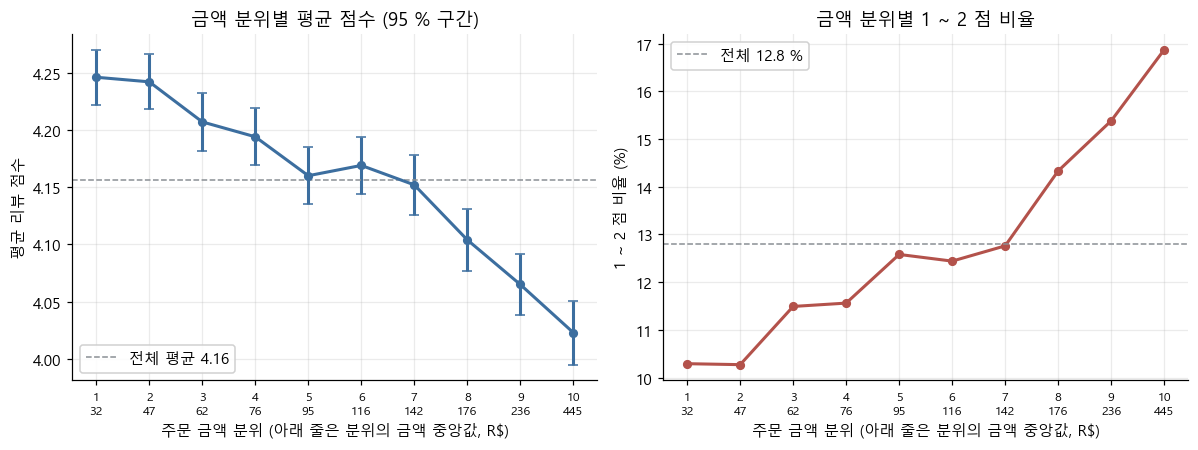

In [10]:
d = dec[dec['decile'] != '전체'].reset_index(drop=True)
overall_avg = dec.loc[dec['decile'] == '전체', 'avg_score'].iloc[0]
overall_low = dec.loc[dec['decile'] == '전체', 'low_pct'].iloc[0]
x = list(range(1, len(d) + 1))
labels = [f'{i}\n{m:,.0f}' for i, m in zip(x, d['median_amount'])]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.errorbar(x, d['avg_score'], yerr=d['ci_half'], color=BLUE, marker='o', ms=5, lw=2, capsize=3)
ax.axhline(overall_avg, color=GRAY, lw=1, ls='--', label=f'전체 평균 {overall_avg:.2f}')
ax.set_ylabel('평균 리뷰 점수')
ax.set_title('금액 분위별 평균 점수 (95 % 구간)')
ax.legend(loc='lower left', framealpha=0.9)

ax = axes[1]
ax.plot(x, d['low_pct'], color=RED, marker='o', ms=5, lw=2)
ax.axhline(overall_low, color=GRAY, lw=1, ls='--', label=f'전체 {overall_low:.1f} %')
ax.set_ylabel('1 ~ 2 점 비율 (%)')
ax.set_title('금액 분위별 1 ~ 2 점 비율')
ax.legend(loc='upper left', framealpha=0.9)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_xlabel('주문 금액 분위 (아래 줄은 분위의 금액 중앙값, R$)')
plt.tight_layout()
plt.show()

**주문 금액이 높을수록 리뷰 점수가 낮다.** 평균 점수가 1 분위(금액 중앙값 32.38) 4.246 에서 10 분위(444.79) 4.023 으로 내려간다.
1 · 2 분위가 4.246 · 4.242, 5 · 6 분위가 4.160 · 4.169 로 거의 같은 것 외에는 분위가 오를 때마다 낮아진다.

1 ~ 2 점 비율은 10.29 % 에서 16.87 % 로, 1 점 비율은 7.48 % 에서 13.48 % 로 오르고 5 점 비율은 61.06 % 에서 57.10 % 로 내려간다.
오르는 폭은 8 분위부터 커진다. 1 ~ 7 분위의 1 ~ 2 점 비율이 10.27 ~ 12.76 % 인데 8 · 9 · 10 분위는 14.33 · 15.38 · 16.87 % 다.

10 분위는 305.55 에서 13,664.08 까지 범위가 넓다. 상품이 둘 이상인 주문의 비율도 1 분위 0.50 % 에서 10 분위 21.91 % 로 올라,
금액이 높은 분위일수록 여러 상품을 산 주문이 섞인다.

최상위 분위와 최하위 분위의 차이, 그리고 10 개 분위를 모두 쓴 추세를 함께 본다.
끝의 두 분위만으로는 가운데 8 개가 어떻게 움직이는지 들어가지 않는다.

- `diff_avg` · `diff_ci_low` · `diff_ci_high` — 평균 점수의 차이(10 분위 − 1 분위)와 구간
- `diff_low_pp` · `diff_low_ci_half` — 1 ~ 2 점 비율의 차이(%p)와 구간의 반폭
- `slope` · `slope_ci_low` · `slope_ci_high` — 분위가 하나 오를 때 평균 점수의 변화와 구간.
  주문 단위로 분위 번호에 점수를 회귀한 기울기

In [11]:
slp=con.execute("""
WITH s AS (
    SELECT amount_decile AS d,
           review_score
    FROM amount_review
),
g AS (
    SELECT d                                                      AS d,
           COUNT(*)                                               AS n,
           AVG(review_score)                                      AS m,
           VAR_SAMP(review_score)                                 AS v,
           AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END) AS low
    FROM s
    WHERE d IN (1, 10)
    GROUP BY d
),
fit AS (
    SELECT regr_slope(review_score, d)                                   AS sl,
           SQRT((regr_syy(review_score, d)
                 - POWER(regr_sxy(review_score, d), 2) / regr_sxx(review_score, d))
                / (regr_count(review_score, d) - 2)
                / regr_sxx(review_score, d))                             AS se
    FROM s
)
SELECT ROUND(hi.m - lo.m, 3)                                                             AS diff_avg,
       ROUND(hi.m - lo.m - 1.96 * SQRT(hi.v / hi.n + lo.v / lo.n), 3)                    AS diff_ci_low,
       ROUND(hi.m - lo.m + 1.96 * SQRT(hi.v / hi.n + lo.v / lo.n), 3)                    AS diff_ci_high,
       ROUND(100 * (hi.low - lo.low), 2)                                                 AS diff_low_pp,
       ROUND(196 * SQRT(hi.low * (1 - hi.low) / hi.n + lo.low * (1 - lo.low) / lo.n), 2) AS diff_low_ci_half,
       ROUND(fit.sl, 4)                                                                  AS slope,
       ROUND(fit.sl - 1.96 * fit.se, 4)                                                  AS slope_ci_low,
       ROUND(fit.sl + 1.96 * fit.se, 4)                                                  AS slope_ci_high
FROM g AS hi
CROSS JOIN g AS lo
CROSS JOIN fit
WHERE hi.d = 10
  AND lo.d = 1
""").df()

slp

,diff_avg,diff_ci_low,diff_ci_high,diff_low_pp,diff_low_ci_half,slope,slope_ci_low,slope_ci_high
0,-0.222,-0.26,-0.185,6.58,0.97,-0.0235,-0.0263,-0.0207


10 분위와 1 분위의 평균 점수 차이는 −0.222 이고 95 % 구간은 −0.260 ~ −0.185 로 0 을 포함하지 않는다.
1 ~ 2 점 비율의 차이는 6.58 %p, 구간의 반폭은 0.97 %p.

10 개 분위를 모두 쓴 기울기는 분위당 −0.0235(−0.0263 ~ −0.0207) 이다. 아홉 칸을 오르면 −0.212 로,
양 끝만 견준 −0.222 와 크기가 비슷하다. 가운데 분위들도 같은 방향으로 늘어서 있다는 뜻이다.

## 5. 조건 2 — 그 차이 중 배송에서 오는 몫

금액 분위마다 약속 위반율과 소요일, 약속 준수 여부로 나눈 평균 점수를 집계한다.
약속 위반은 `days_vs_promise > 0` 인 주문.

- `late_pct` — 약속 위반율
- `median_days` — 배송 소요일의 중앙값
- `median_days_kept` — 약속을 지킨 주문의 배송 소요일 중앙값
- `kept_orders` · `avg_kept` · `ci_kept` — 약속을 지킨 주문의 수, 평균 점수, 95 % 구간의 반폭
- `avg_late` — 약속을 어긴 주문의 평균 점수

In [12]:
dly = con.execute("""
SELECT LPAD(CAST(amount_decile AS VARCHAR), 2, '0')                                AS decile,
       COUNT(*)                                                                   AS orders,
       ROUND(100.0 * AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END), 2) AS late_pct,
       MEDIAN(delivery_days)                                                      AS median_days,
       MEDIAN(delivery_days) FILTER (days_vs_promise <= 0)                        AS median_days_kept,
       COUNT(*) FILTER (days_vs_promise <= 0)                                     AS kept_orders,
       ROUND(AVG(review_score) FILTER (days_vs_promise <= 0), 3)                  AS avg_kept,
       ROUND(1.96 * STDDEV_SAMP(review_score) FILTER (days_vs_promise <= 0)
             / SQRT(COUNT(*) FILTER (days_vs_promise <= 0)), 3)                   AS ci_kept,
       ROUND(AVG(review_score) FILTER (days_vs_promise > 0), 3)                   AS avg_late
FROM amount_review
GROUP BY amount_decile
ORDER BY decile
""").df()
dly

,decile,orders,late_pct,median_days,median_days_kept,kept_orders,avg_kept,ci_kept,avg_late
0,01,9556,5.36,8.0,8.0,9044,4.347,0.022,2.463
1,02,9556,5.85,9.0,9.0,8997,4.362,0.022,2.320
2,03,9556,6.05,10.0,9.0,8978,4.329,0.023,2.310
3,04,9556,6.60,10.0,10.0,8925,4.332,0.023,2.250
4,05,9556,6.84,10.0,10.0,8902,4.295,0.024,2.321
5,06,9556,6.75,10.0,10.0,8911,4.302,0.024,2.324
6,07,9556,6.99,11.0,10.0,8888,4.294,0.024,2.272
7,08,9556,7.36,11.0,10.0,8853,4.257,0.025,2.179
8,09,9556,7.03,11.0,11.0,8884,4.211,0.026,2.128
9,10,9556,7.91,11.0,11.0,8800,4.179,0.027,2.214


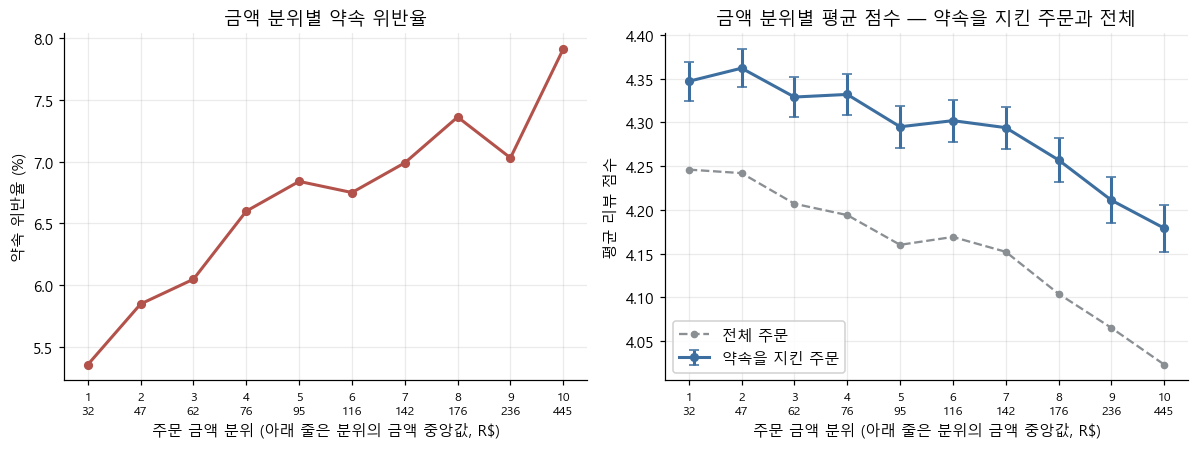

In [13]:
x = list(range(1, len(dly) + 1))
d_all = dec[dec['decile'] != '전체'].reset_index(drop=True)
labels = [f'{i}\n{m:,.0f}' for i, m in zip(x, d_all['median_amount'])]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(x, dly['late_pct'], color=RED, marker='o', ms=5, lw=2)
ax.set_ylabel('약속 위반율 (%)')
ax.set_title('금액 분위별 약속 위반율')

ax = axes[1]
ax.errorbar(x, dly['avg_kept'], yerr=dly['ci_kept'], color=BLUE, marker='o', ms=5, lw=2, capsize=3,
            label='약속을 지킨 주문')
ax.plot(x, d_all['avg_score'], color=GRAY, marker='o', ms=4, lw=1.5, ls='--', label='전체 주문')
ax.set_ylabel('평균 리뷰 점수')
ax.set_title('금액 분위별 평균 점수 — 약속을 지킨 주문과 전체')
ax.legend(loc='lower left', framealpha=0.9)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_xlabel('주문 금액 분위 (아래 줄은 분위의 금액 중앙값, R$)')
plt.tight_layout()
plt.show()

금액이 높은 분위일수록 약속 위반율이 높다. 1 분위 5.36 % 에서 10 분위 7.91 % 로 오르고,
배송 소요일의 중앙값도 8 일에서 11 일로 길어지며, 약속을 지킨 주문만 따져도 8 일에서 11 일이다.

**약속을 지킨 주문끼리도 금액이 높을수록 점수가 낮다.** 약속을 지킨 주문의 평균이 1 분위 4.347 에서 10 분위 4.179 로 내려간다.
약속을 어긴 주문은 분위마다 2.128 ~ 2.463 으로 약속을 지킨 주문보다 2 점 가까이 낮다.

최상위 분위와 최하위 분위의 평균 격차를 약속 위반에서 온 몫과 나머지로 나누고,
약속을 지킨 주문끼리의 차이도 구간과 함께 낸다.

- `late_share_part` — 위반 비중이 달라서 생긴 몫. 위반율 차이 × 최하위 분위에서 위반 주문과 준수 주문의 점수 차이
- `within_part` — 약속 준수 여부가 같은 주문끼리의 점수 차이에서 온 몫. 두 몫의 합은 격차 `gap` 과 같다
- `late_share_pct` — 위반 비중의 몫이 격차에서 차지하는 비율
- `kept_diff` · `kept_ci_low` · `kept_ci_high` — 약속을 지킨 주문의 10 분위와 1 분위 평균 점수 차이와 95 % 구간

In [14]:
con.execute("""
WITH g AS (
    SELECT amount_decile                                            AS d,
           AVG(review_score)                                        AS m,
           AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END) AS p,
           AVG(review_score)      FILTER (days_vs_promise <= 0)     AS k,
           VAR_SAMP(review_score) FILTER (days_vs_promise <= 0)     AS kv,
           COUNT(*)               FILTER (days_vs_promise <= 0)     AS kn,
           AVG(review_score)      FILTER (days_vs_promise > 0)      AS l
    FROM amount_review
    WHERE amount_decile IN (1, 10)
    GROUP BY amount_decile
)
SELECT ROUND(t.m - b.m, 3)                                            AS gap,
       ROUND((t.p - b.p) * (b.l - b.k), 3)                            AS late_share_part,
       ROUND((1 - t.p) * (t.k - b.k) + t.p * (t.l - b.l), 3)          AS within_part,
       ROUND(100 * (t.p - b.p) * (b.l - b.k) / (t.m - b.m), 1)        AS late_share_pct,
       ROUND(t.k - b.k, 3)                                            AS kept_diff,
       ROUND(t.k - b.k - 1.96 * SQRT(t.kv / t.kn + b.kv / b.kn), 3)   AS kept_ci_low,
       ROUND(t.k - b.k + 1.96 * SQRT(t.kv / t.kn + b.kv / b.kn), 3)   AS kept_ci_high
FROM g AS t
CROSS JOIN g AS b
WHERE t.d = 10
  AND b.d = 1
""").df()

,gap,late_share_part,within_part,late_share_pct,kept_diff,kept_ci_low,kept_ci_high
0,-0.222,-0.048,-0.174,21.6,-0.168,-0.203,-0.133


**격차의 대부분은 약속 위반에서 오지 않는다.** 1 분위와 10 분위의 격차 −0.222 중 위반 비중이 달라서 생긴 몫이
−0.048(21.6 %), 약속 준수 여부가 같은 주문끼리의 차이에서 온 몫이 −0.174(78.4 %) 다.

약속을 지킨 주문끼리의 차이는 −0.168 이고 95 % 구간이 −0.203 ~ −0.133 으로 0 을 포함하지 않는다.

약속 준수 여부로 나눠 같은 기울기를 구한다. 위반이 섞이지 않은 주문 안에서도 분위를 따라 내려가는지 본다.

- `orders` — 주문 수
- `slope` · `slope_ci_low` · `slope_ci_high` — 분위가 하나 오를 때 평균 점수의 변화와 95 % 구간

In [15]:
con.execute("""
WITH s AS (
    SELECT '1. 전체 주문'      AS grp, amount_decile AS d, review_score FROM amount_review
    UNION ALL
    SELECT '2. 약속을 지킨 주문', amount_decile,         review_score FROM amount_review
    WHERE days_vs_promise <= 0
    UNION ALL
    SELECT '3. 약속을 어긴 주문', amount_decile,         review_score FROM amount_review
    WHERE days_vs_promise > 0
),
f AS (
    SELECT grp,
           COUNT(*)                           AS orders,
           regr_slope(review_score, d)        AS sl,
           SQRT((regr_syy(review_score, d)
                 - POWER(regr_sxy(review_score, d), 2) / regr_sxx(review_score, d))
                / (regr_count(review_score, d) - 2)
                / regr_sxx(review_score, d)) AS se
    FROM s
    GROUP BY grp
)
SELECT grp,
       orders,
       ROUND(sl, 4)              AS slope,
       ROUND(sl - 1.96 * se, 4)  AS slope_ci_low,
       ROUND(sl + 1.96 * se, 4)  AS slope_ci_high
FROM f
ORDER BY grp
""").df()

,grp,orders,slope,slope_ci_low,slope_ci_high
0,1. 전체 주문,95560,-0.0235,-0.0263,-0.0207
1,2. 약속을 지킨 주문,89182,-0.0184,-0.0210,-0.0157
2,3. 약속을 어긴 주문,6378,-0.0245,-0.0381,-0.0110


약속을 지킨 주문 안에서도 기울기가 남는다. 전체 −0.0235(−0.0263 ~ −0.0207) 에 견주어 약속을 지킨 주문은
−0.0184(−0.0210 ~ −0.0157) 로 78 % 크기이며 구간이 0 을 포함하지 않는다.
약속을 어긴 주문도 −0.0245(−0.0381 ~ −0.0110) 로 방향이 같다.

약속을 지킨 주문 안에서도 금액이 높은 분위일수록 소요일이 길다. 소요일의 영향을 제외하기 위해 소요일 구간을 나누고 그 안에서 같은 기울기를 구한다.
구간은 06 에서 쓴 것과 같다.

- `band` — 배송 소요일 구간
- `orders` · `avg_score` — 약속을 지킨 주문의 수와 평균 점수
- `min_decile_n` — 그 구간에서 주문이 가장 적은 금액 분위의 주문 수
- `slope` · `slope_ci_low` · `slope_ci_high` — 분위가 하나 오를 때 평균 점수의 변화와 95 % 구간

In [16]:
bnd=con.execute("""
WITH s AS (
    SELECT CASE WHEN delivery_days <= 7  THEN '1. 0 ~ 7 일'
                WHEN delivery_days <= 14 THEN '2. 8 ~ 14 일'
                WHEN delivery_days <= 21 THEN '3. 15 ~ 21 일'
                WHEN delivery_days <= 30 THEN '4. 22 ~ 30 일'
                ELSE                          '5. 31 일 이상' END AS band,
           amount_decile                                          AS d,
           review_score
    FROM amount_review
    WHERE days_vs_promise <= 0
),
f AS (
    SELECT band,
           COUNT(*)                           AS orders,
           AVG(review_score)                  AS avg_score,
           regr_slope(review_score, d)        AS sl,
           SQRT((regr_syy(review_score, d)
                 - POWER(regr_sxy(review_score, d), 2) / regr_sxx(review_score, d))
                / (regr_count(review_score, d) - 2)
                / regr_sxx(review_score, d)) AS se
    FROM s
    GROUP BY band
),
per_d AS (
    SELECT band, MIN(n) AS min_decile_n
    FROM (SELECT band, d, COUNT(*) AS n FROM s GROUP BY band, d)
    GROUP BY band
)
SELECT f.band,
       f.orders,
       ROUND(f.avg_score, 3)       AS avg_score,
       per_d.min_decile_n,
       ROUND(f.sl, 4)              AS slope,
       ROUND(f.sl - 1.96 * f.se, 4) AS slope_ci_low,
       ROUND(f.sl + 1.96 * f.se, 4) AS slope_ci_high
FROM f
JOIN per_d USING (band)
ORDER BY f.band
""").df()

bnd

,band,orders,avg_score,min_decile_n,slope,slope_ci_low,slope_ci_high
0,1. 0 ~ 7 일,30442,4.413,2428,-0.0116,-0.0157,-0.0075
1,2. 8 ~ 14 일,37361,4.308,3247,-0.0119,-0.0159,-0.0078
2,3. 15 ~ 21 일,15414,4.161,1030,-0.0140,-0.0209,-0.0072
3,4. 22 ~ 30 일,5171,3.940,261,-0.0208,-0.0335,-0.0081
4,5. 31 일 이상,794,3.628,24,-0.0247,-0.0620,0.0127


**소요일의 영향을 제외해도 기울기가 남는다.** 0 ~ 7 일 −0.0116, 8 ~ 14 일 −0.0119, 15 ~ 21 일 −0.0140, 22 ~ 30 일 −0.0208 로
네 구간 모두 95 % 구간이 0 을 포함하지 않는다. 31 일 이상은 −0.0247 이나 구간이 −0.0620 ~ 0.0127 로 0 을 포함하며,
그 구간의 약속을 지킨 주문이 794 건, 가장 적은 금액 분위가 24 건이다.

0 ~ 21 일 세 구간의 기울기는 약속을 지킨 주문 전체의 −0.0184 보다 완만하고, 22 ~ 30 일 · 31 일 이상은 더 가파르다. 소요일이 긴 구간일수록 기울기가 커진다.

전체 기울기를 배송이 설명하는 몫과 남는 몫으로 나눈다. 약속 준수 여부와 소요일의 영향을 차례로 제외하며
기울기가 줄어드는 폭이 각각의 몫이다.

- `1. 약속 위반 구성` — 전체 기울기와 약속을 지킨 주문의 기울기의 차
- `2. 소요일 구성` — 약속을 지킨 주문의 기울기와 소요일 구간 안 기울기(구간별 기울기를 구간 안 분위의 흩어진 정도 `regr_sxx` 로 가중 평균한 값. 구간마다 평균을 따로 두고 기울기 하나를 맞춘 회귀의 기울기와 같다)의 차
- `3. 남는 몫` — 소요일의 영향까지 제외하고도 남는 기울기
- `pct` — 전체 기울기에서 차지하는 비율

약속을 어긴 주문은 그 안의 기울기가 더 가파르므로, 약속 위반 구성의 몫에는 위반 비중의 차이 외에 그 몫이 조금 섞여 있다.

In [17]:
dsh=con.execute("""
WITH kept AS (
    SELECT amount_decile AS d,
           delivery_days,
           review_score
    FROM amount_review
    WHERE days_vs_promise <= 0
),
whole AS (
    SELECT regr_slope(review_score, amount_decile) AS sl
    FROM amount_review
),
kept_fit AS (
    SELECT regr_slope(review_score, d) AS sl
    FROM kept
),
band_fit AS (
    SELECT CASE WHEN delivery_days <= 7  THEN 1
                WHEN delivery_days <= 14 THEN 2
                WHEN delivery_days <= 21 THEN 3
                WHEN delivery_days <= 30 THEN 4
                ELSE                          5 END AS band,
           regr_sxx(review_score, d)               AS sxx,
           regr_slope(review_score, d)             AS sl
    FROM kept
    GROUP BY band
),
within AS (
    SELECT SUM(sxx * sl) / SUM(sxx) AS sl
    FROM band_fit
)
SELECT '1. 약속 위반 구성'                          AS part,
       ROUND(w.sl - k.sl, 4)                      AS slope_part,
       ROUND(100 * (w.sl - k.sl) / w.sl, 1)       AS pct
FROM whole AS w
CROSS JOIN kept_fit AS k

UNION ALL
SELECT '2. 소요일 구성',
       ROUND(k.sl - i.sl, 4),
       ROUND(100 * (k.sl - i.sl) / w.sl, 1)
FROM whole AS w
CROSS JOIN kept_fit AS k
CROSS JOIN within AS i

UNION ALL
SELECT '3. 남는 몫',
       ROUND(i.sl, 4),
       ROUND(100 * i.sl / w.sl, 1)
FROM whole AS w
CROSS JOIN within AS i

UNION ALL
SELECT '4. 전체 기울기',
       ROUND(w.sl, 4),
       100.0
FROM whole AS w

ORDER BY part
""").df()

dsh

,part,slope_part,pct
0,1. 약속 위반 구성,-0.0051,21.9
1,2. 소요일 구성,-0.0056,23.9
2,3. 남는 몫,-0.0127,54.2
3,4. 전체 기울기,-0.0235,100.0


**배송으로 설명되는 몫은 기울기의 절반에 조금 못 미친다.** −0.0235 중 약속 위반 구성이 −0.0051(21.9 %),
소요일 구성이 −0.0056(23.9 %) 으로 둘을 합쳐 45.8 % 이고, 배송으로 설명되지 않는 몫이 −0.0127(54.2 %) 다.

약속 위반만 따지면 21.9 % 가 설명되고, 소요일까지 더하면 45.8 % 가 된다.
앞의 1 분위와 10 분위 분해에서 약속 위반이 설명한 21.6 % 는 이 21.9 % 와 같은 자리의 수치다.

운임은 배송 거리와 무게를 반영해 매겨지므로 운임이 높은 주문은 배송도 다를 수 있다.
운임으로 10 분위를 나눠 소요일과 약속 위반율을 본다.

- `median_freight` · `median_amount` — 운임 분위의 운임과 주문 금액의 중앙값
- `median_days` · `late_pct` — 배송 소요일의 중앙값과 약속 위반율
- `avg_score` — 평균 리뷰 점수

In [18]:
frt=con.execute("""
WITH f AS (
    SELECT freight_sum,
           order_amount,
           delivery_days,
           days_vs_promise,
           review_score,
           NTILE(10) OVER (ORDER BY freight_sum, order_id) AS fd
    FROM amount_review
)
SELECT LPAD(CAST(fd AS VARCHAR), 2, '0')                                           AS freight_decile,
       COUNT(*)                                                                   AS orders,
       ROUND(MEDIAN(freight_sum), 2)                                              AS median_freight,
       ROUND(MEDIAN(order_amount), 2)                                             AS median_amount,
       MEDIAN(delivery_days)                                                      AS median_days,
       ROUND(100.0 * AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END), 2) AS late_pct,
       ROUND(AVG(review_score), 3)                                                AS avg_score
FROM f
GROUP BY fd
ORDER BY freight_decile
""").df()

frt

,freight_decile,orders,median_freight,median_amount,median_days,late_pct,avg_score
0,01,9556,7.87,48.78,5.0,4.21,4.344
1,02,9556,11.85,69.73,7.0,4.61,4.283
2,03,9556,13.83,80.65,9.0,5.14,4.264
3,04,9556,15.11,68.12,11.0,6.73,4.192
4,05,9556,16.34,102.03,12.0,7.45,4.181
5,06,9556,17.99,91.16,12.0,7.52,4.174
6,07,9556,19.75,135.00,12.0,7.64,4.186
7,08,9556,23.99,133.21,12.0,7.45,4.137
8,09,9556,33.08,161.08,13.0,7.65,3.924
9,10,9556,54.70,261.93,13.0,8.34,3.875


**운임이 높은 주문은 배송이 오래 걸리고 약속도 더 자주 어긴다.** 운임 1 분위(중앙값 7.87) 의 소요일 중앙값 5 일 ·
위반율 4.21 % 가 10 분위(54.70) 에서 13 일 · 8.34 % 가 된다. 평균 점수는 4.344 에서 3.875 로 −0.469 내려간다.

이 격차는 금액 분위의 −0.222 보다 크다. 다만 운임 분위를 따라 주문 금액 중앙값도 48.78 에서 261.93 으로 오르므로
두 축이 겹쳐 있고, 어느 쪽이 얼마나 움직이는지는 이 표로 가르지 못한다.

## 6. 조건 3 — 그 차이 중 카테고리 구성에서 오는 몫

카테고리 하나로만 이루어진 주문을 쓴다. 카테고리 안에서 금액을 10 분위로 나누려면 분위마다 주문이 충분해야 하므로
주문 수 기준에 따라 남는 규모를 먼저 센다.

In [19]:
con.execute("""
WITH c AS (
    SELECT category,
           COUNT(*) AS n
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
)
SELECT '1. 카테고리 하나인 주문' AS item,
       CAST(SUM(n) AS BIGINT)  AS orders,
       COUNT(*)                AS categories
FROM c

UNION ALL
SELECT '2. 그중 주문 500 건 이상 카테고리',
       CAST(SUM(n) FILTER (n >= 500) AS BIGINT),
       COUNT(*) FILTER (n >= 500)
FROM c

UNION ALL
SELECT '3. 그중 주문 1,000 건 이상 카테고리',
       CAST(SUM(n) FILTER (n >= 1000) AS BIGINT),
       COUNT(*) FILTER (n >= 1000)
FROM c

ORDER BY item
""").df()

,item,orders,categories
0,1. 카테고리 하나인 주문,93466,73
1,2. 그중 주문 500 건 이상 카테고리,86314,25
2,"3. 그중 주문 1,000 건 이상 카테고리",82667,20


카테고리 하나인 주문 93,466 건이 73 개 카테고리에 흩어져 있다. 주문 500 건 이상인 카테고리는 25 개이고
주문 86,314 건으로 카테고리 하나인 주문의 92.35 %, 표본 95,560 건의 90.32 % 다.
1,000 건 이상으로 올리면 20 개 · 82,667 건으로 5 개 카테고리와 3,647 건이 더 빠진다.

500 건이면 10 분위마다 50 건 이상이 남고, 카테고리별 비교에 쓰는 상하위 20 % 는 100 건 이상이 되므로
500 건을 기준으로 쓴다. 분위끼리 모아 보는 집계에서는 분위마다 8,600 건이 넘는다.

금액이 높은 주문이 비싼 카테고리에 몰리고 그 카테고리의 점수가 원래 낮다면, 4 의 관계는 카테고리 구성이 만든 것이다.
그렇다면 카테고리의 가격대와 그 카테고리의 점수 사이에 관계가 있어야 한다.
주문 500 건 이상인 카테고리마다 금액 중앙값과 평균 점수를 구하고, 25 개 카테고리를 합친 값도 마지막 줄에 둔다.

- `orders` — 카테고리의 주문 수
- `median_amount` · `avg_score` — 주문 금액의 중앙값과 평균 리뷰 점수

이어서 둘의 상관계수를 본다. 카테고리가 25 개뿐이라 95 % 구간을 붙인다.

- `corr_amount_score` · `corr_log_amount_score` — 금액 중앙값, 로그 금액 중앙값과 평균 점수의 상관계수
- `ci_low` · `ci_high` · `log_ci_low` · `log_ci_high` — Fisher 변환으로 구한 95 % 구간

In [20]:
con.execute("""
WITH big AS (
    SELECT category
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
    HAVING COUNT(*) >= 500
),
s AS (
    SELECT a.category,
           a.order_amount,
           a.review_score
    FROM amount_review AS a
    JOIN big USING (category)
)
SELECT CASE WHEN GROUPING(category) = 1 THEN '전체 25 개 카테고리'
            ELSE category END                  AS category,
       COUNT(*)                                AS orders,
       ROUND(MEDIAN(order_amount), 2)          AS median_amount,
       ROUND(AVG(review_score), 3)             AS avg_score
FROM s
GROUP BY GROUPING SETS ((category), ())
ORDER BY GROUPING(category), median_amount DESC
""").df()

,category,orders,median_amount,avg_score
0,office_furniture,1224,205.65,3.668
1,watches_gifts,5409,158.52,4.129
2,cool_stuff,3457,148.15,4.246
3,musical_instruments,597,143.21,4.243
4,luggage_accessories,1000,127.87,4.381
5,small_appliances,598,125.99,4.274
6,construction_tools_construction,714,121.11,4.150
7,pet_shop,1661,114.80,4.288
8,perfumery,3023,111.21,4.267
9,auto,3747,110.91,4.161


In [21]:
cor=con.execute("""
WITH c AS (
    SELECT category,
           MEDIAN(order_amount) AS median_amount,
           AVG(review_score)    AS avg_score
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
    HAVING COUNT(*) >= 500
),
r AS (
    SELECT COUNT(*)                           AS n,
           CORR(median_amount, avg_score)     AS r1,
           CORR(LN(median_amount), avg_score) AS r2
    FROM c
)
SELECT n                                                        AS categories,
       ROUND(r1, 3)                                             AS corr_amount_score,
       ROUND(TANH(ATANH(r1) - 1.96 / SQRT(n - 3)), 3)           AS ci_low,
       ROUND(TANH(ATANH(r1) + 1.96 / SQRT(n - 3)), 3)           AS ci_high,
       ROUND(r2, 3)                                             AS corr_log_amount_score,
       ROUND(TANH(ATANH(r2) - 1.96 / SQRT(n - 3)), 3)           AS log_ci_low,
       ROUND(TANH(ATANH(r2) + 1.96 / SQRT(n - 3)), 3)           AS log_ci_high
FROM r
""").df()

cor

,categories,corr_amount_score,ci_low,ci_high,corr_log_amount_score,log_ci_low,log_ci_high
0,25,-0.311,-0.629,0.096,-0.137,-0.505,0.273


카테고리의 가격대로는 그 카테고리의 점수를 가늠하기 어렵다. 금액 중앙값과 평균 점수의 상관계수가 −0.311 이나
95 % 구간이 −0.629 ~ 0.096 으로 0 을 포함하고, 로그 금액으로는 −0.137(−0.505 ~ 0.273) 이다. 카테고리가 25 개뿐이라 구간이 넓다.

점수가 가격대 순서로 늘어서 있지도 않다. 금액 중앙값이 가장 높은 office_furniture(205.65) 가 평균 3.668 로 가장 낮지만,
가장 낮은 electronics(37.80) · telephony(45.22) 도 4.131 · 4.060 으로 25 개 카테고리를 합친 평균 4.164 를 밑돈다.

구간이 0 을 포함한다고 해서 관계가 없다는 뜻은 아니므로, 이 비교만으로는 카테고리 구성을 배제하지 못한다.
판단은 아래의 같은 카테고리 안 비교에 둔다.

같은 카테고리 안의 비교. 주문 500 건 이상인 카테고리마다 금액을 10 분위로 나누고 분위끼리 모아 집계한다.
카테고리의 가격대 차이가 빠지고 같은 카테고리 안에서 더 비싼 주문인지만 남는다.

- `decile` — 카테고리 안의 금액 10 분위. 1 이 가장 낮다
- `avg_score` · `ci_half` · `low_pct` — 평균 점수, 95 % 구간의 반폭, 1 ~ 2 점 비율
- `late_pct` · `avg_kept` — 약속 위반율과 약속을 지킨 주문의 평균 점수

In [22]:
con.execute("""
WITH big AS (
    SELECT category
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
    HAVING COUNT(*) >= 500
),
q AS (
    SELECT a.*,
           NTILE(10) OVER (PARTITION BY a.category ORDER BY a.order_amount, a.order_id) AS decile
    FROM amount_review AS a
    JOIN big USING (category)
)
SELECT decile,
       COUNT(*)                                                                   AS orders,
       ROUND(AVG(review_score), 3)                                                AS avg_score,
       ROUND(1.96 * STDDEV_SAMP(review_score) / SQRT(COUNT(*)), 3)                AS ci_half,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END), 2)   AS low_pct,
       ROUND(100.0 * AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END), 2) AS late_pct,
       ROUND(AVG(review_score) FILTER (days_vs_promise <= 0), 3)                  AS avg_kept
FROM q
GROUP BY decile
ORDER BY decile
""").df()

,decile,orders,avg_score,ci_half,low_pct,late_pct,avg_kept
0,1,8644,4.259,0.025,9.83,5.18,4.354
1,2,8642,4.240,0.025,10.54,5.47,4.353
2,3,8641,4.203,0.026,11.24,6.35,4.334
3,4,8637,4.204,0.026,11.33,6.60,4.342
4,5,8632,4.167,0.027,12.41,7.18,4.312
5,6,8628,4.153,0.027,12.84,6.91,4.295
6,7,8626,4.156,0.027,12.64,7.48,4.314
7,8,8623,4.137,0.027,13.20,6.99,4.279
8,9,8621,4.090,0.029,14.88,7.39,4.239
9,10,8620,4.032,0.030,16.68,7.90,4.190


**같은 카테고리 안에서도 금액이 높을수록 점수가 낮다.** 카테고리 안의 금액 10 분위를 모으면
평균 점수가 1 분위 4.259 에서 10 분위 4.032 로 내려가고 차이는 −0.227 이다.
1 ~ 2 점 비율은 9.83 % 에서 16.68 % 로 오른다.

약속을 지킨 주문만 보아도 4.354 에서 4.190 으로 −0.164 다. 약속 위반율은 5.18 % 에서 7.90 % 로 오른다.

카테고리 가격대의 몫을 재려면 같은 주문 안에서 두 척도를 견줘야 한다.
주문 500 건 이상인 카테고리의 주문만 놓고, 이 주문 전체를 금액 10 분위로 다시 나눈 분위와 카테고리 안에서 나눈 분위로 각각 기울기를 구한다.
둘 다 같은 주문을 주문 수가 같은 10 칸으로 나눈 것이라 한 칸의 뜻이 같다.
전체 금액 분위에는 카테고리 사이의 가격대 차이가 들어 있고, 카테고리 안 분위에는 빠져 있다.

- `scale` — 가로축으로 쓴 분위
- `diff_avg` — 10 분위와 1 분위의 평균 점수 차이
- `slope` · `slope_ci_low` · `slope_ci_high` — 분위가 하나 오를 때 평균 점수의 변화와 95 % 구간

In [23]:
csl=con.execute("""
WITH big AS (
    SELECT category
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
    HAVING COUNT(*) >= 500
),
s AS (
    SELECT NTILE(10) OVER (ORDER BY a.order_amount, a.order_id)                          AS d,
           NTILE(10) OVER (PARTITION BY a.category ORDER BY a.order_amount, a.order_id) AS cd,
           a.review_score
    FROM amount_review AS a
    JOIN big USING (category)
),
long AS (
    SELECT '1. 전체 금액 분위'   AS scale, d  AS x, review_score FROM s
    UNION ALL
    SELECT '2. 카테고리 안 분위', cd,        review_score FROM s
),
f AS (
    SELECT scale,
           COUNT(*)                                                           AS orders,
           AVG(review_score) FILTER (x = 10) - AVG(review_score) FILTER (x = 1) AS diff_avg,
           regr_slope(review_score, x)                                        AS sl,
           SQRT((regr_syy(review_score, x)
                 - POWER(regr_sxy(review_score, x), 2) / regr_sxx(review_score, x))
                / (regr_count(review_score, x) - 2)
                / regr_sxx(review_score, x))                                  AS se
    FROM long
    GROUP BY scale
)
SELECT scale,
       orders,
       ROUND(diff_avg, 3)        AS diff_avg,
       ROUND(sl, 4)              AS slope,
       ROUND(sl - 1.96 * se, 4)  AS slope_ci_low,
       ROUND(sl + 1.96 * se, 4)  AS slope_ci_high
FROM f
ORDER BY scale
""").df()

csl

,scale,orders,diff_avg,slope,slope_ci_low,slope_ci_high
0,1. 전체 금액 분위,86314,-0.206,-0.0202,-0.0232,-0.0173
1,2. 카테고리 안 분위,86314,-0.227,-0.0217,-0.0246,-0.0187


**카테고리의 가격대를 걷어내도 기울기가 줄지 않는다.** 같은 86,314 건에서 전체 금액 분위의 기울기가 −0.0202(−0.0232 ~ −0.0173),
카테고리 안 분위의 기울기가 −0.0217(−0.0246 ~ −0.0187) 이다. 1 분위와 10 분위의 격차도 −0.206 과 −0.227 이다.
카테고리 구성이 설명하는 몫은 이 비교에서 보이지 않는다.
이 비교는 카테고리의 영향만 제외한 것으로, 배송과 카테고리의 영향을 한꺼번에 제외한 기울기는 확인하지 않았다.

4 의 전체 기울기 −0.0235 는 이 밖의 9,246 건까지 포함한 값이라 여기서는 견주지 않는다.

카테고리마다 금액 하위 20 %(1 · 2 분위) 와 상위 20 %(9 · 10 분위) 의 평균 점수를 견준다.

- `lo_median` · `hi_median` — 하위 20 % 와 상위 20 % 의 금액 중앙값
- `lo_avg` · `hi_avg` · `gap` — 두 쪽의 평균 점수와 차이(상위 − 하위)
- `ci_half` — 차이의 95 % 구간 반폭
- `direction` — 구간 전체가 음수면 `낮음`, 양수면 `높음`, 0 을 포함하면 `구간이 0에 걸침`

In [24]:
cat = con.execute("""
WITH big AS (
    SELECT category
    FROM amount_review
    WHERE category IS NOT NULL
    GROUP BY category
    HAVING COUNT(*) >= 500
),
q AS (
    SELECT a.category,
           a.order_amount,
           a.review_score,
           NTILE(10) OVER (PARTITION BY a.category ORDER BY a.order_amount, a.order_id) AS d
    FROM amount_review AS a
    JOIN big USING (category)
),
per_cat AS (
    SELECT category,
           COUNT(*)                              AS orders,
           MEDIAN(order_amount) FILTER (d <= 2)  AS lo_median,
           MEDIAN(order_amount) FILTER (d >= 9)  AS hi_median,
           AVG(review_score)    FILTER (d <= 2)  AS lo_avg,
           AVG(review_score)    FILTER (d >= 9)  AS hi_avg,
           1.96 * SQRT(VAR_SAMP(review_score) FILTER (d <= 2) / COUNT(*) FILTER (d <= 2)
                     + VAR_SAMP(review_score) FILTER (d >= 9) / COUNT(*) FILTER (d >= 9)) AS ci_half
    FROM q
    GROUP BY category
)
SELECT category,
       orders,
       ROUND(lo_median, 2)         AS lo_median,
       ROUND(hi_median, 2)         AS hi_median,
       ROUND(lo_avg, 3)            AS lo_avg,
       ROUND(hi_avg, 3)            AS hi_avg,
       ROUND(hi_avg - lo_avg, 3)   AS gap,
       ROUND(ci_half, 3)           AS ci_half,
       CASE WHEN hi_avg - lo_avg + ci_half < 0 THEN '낮음'
            WHEN hi_avg - lo_avg - ci_half > 0 THEN '높음'
            ELSE                                   '구간이 0에 걸침' END AS direction
FROM per_cat
ORDER BY gap
""").df()
cat

,category,orders,lo_median,hi_median,lo_avg,hi_avg,gap,ci_half,direction
0,baby,2686,46.14,301.36,4.236,3.797,-0.439,0.165,낮음
1,fashion_bags_accessories,1785,40.10,193.90,4.385,4.025,-0.360,0.179,낮음
2,consoles_games,994,35.00,390.77,4.350,4.035,-0.315,0.242,낮음
3,auto,3747,35.78,359.54,4.263,3.965,-0.297,0.133,낮음
4,furniture_decor,6012,49.14,276.47,4.214,3.938,-0.276,0.108,낮음
5,computers_accessories,6435,41.28,279.81,4.206,3.937,-0.269,0.103,낮음
6,bed_bath_table,8973,51.84,230.11,4.129,3.878,-0.251,0.090,낮음
7,office_furniture,1224,126.67,459.55,3.890,3.643,-0.247,0.253,구간이 0에 걸침
8,telephony,4035,29.31,216.83,4.218,3.971,-0.246,0.125,낮음
9,garden_tools,3353,53.90,287.12,4.314,4.070,-0.244,0.134,낮음


In [25]:
con.execute("""
SELECT direction,
       COUNT(*)                    AS categories,
       CAST(SUM(orders) AS BIGINT) AS orders
FROM cat
GROUP BY direction
ORDER BY direction
""").df()

,direction,categories,orders
0,구간이 0에 걸침,10,17622
1,낮음,14,65669
2,높음,1,3023


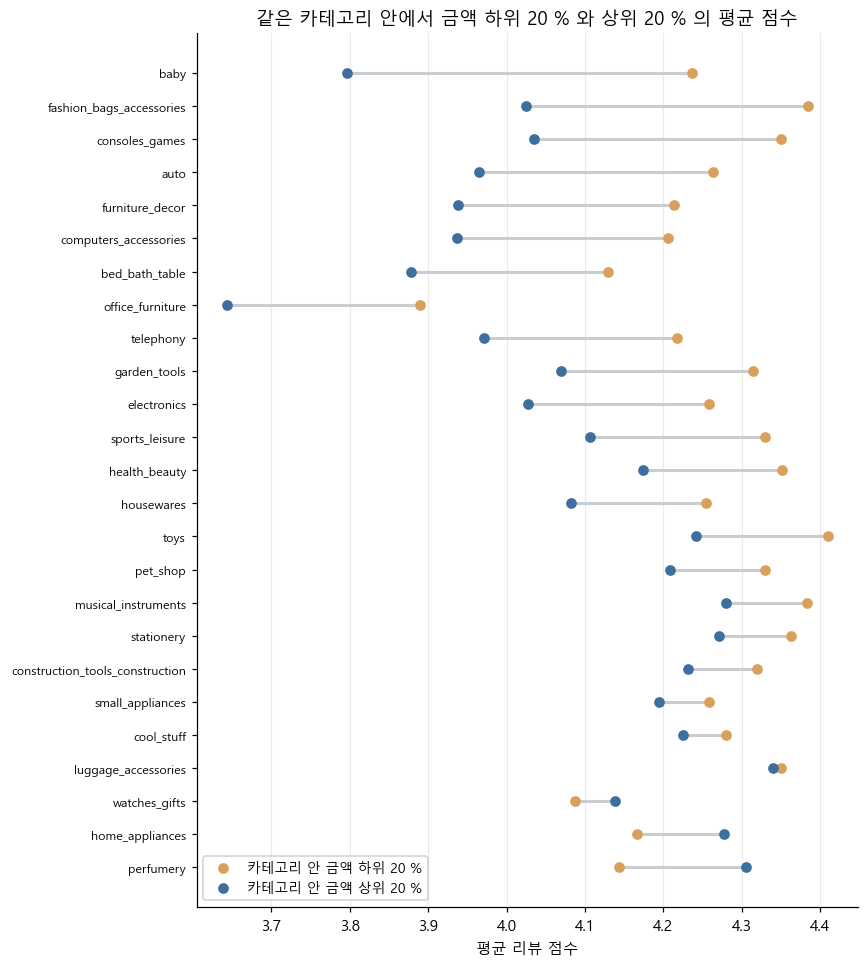

In [26]:
c = cat.sort_values('gap', ascending=False).reset_index(drop=True)
y = list(range(len(c)))

fig, ax = plt.subplots(figsize=(8, 0.3 * len(c) + 1.4))
ax.hlines(y, c['lo_avg'], c['hi_avg'], color='#C9CDD2', lw=2)
ax.scatter(c['lo_avg'], y, color=SAND, s=36, zorder=3, label='카테고리 안 금액 하위 20 %')
ax.scatter(c['hi_avg'], y, color=BLUE, s=36, zorder=3, label='카테고리 안 금액 상위 20 %')
ax.set_yticks(y)
ax.set_yticklabels(c['category'], fontsize=8)
ax.set_xlabel('평균 리뷰 점수')
ax.set_title('같은 카테고리 안에서 금액 하위 20 % 와 상위 20 % 의 평균 점수')
ax.legend(loc='lower left', framealpha=0.9, fontsize=9)
ax.grid(axis='y', alpha=0)
plt.tight_layout()
plt.show()

25 개 카테고리 중 22 개에서 금액 상위 20 % 의 평균이 하위 20 % 보다 낮다.
차이의 구간이 0 을 포함하지 않는 `낮음` 이 14 개로 주문 65,669 건(76.08 %), 구간이 0에 걸친 카테고리가 10 개 · 17,622 건,
상위 20 % 가 더 높은 `높음` 은 perfumery 1 개(+0.163) · 3,023 건이다. 구간이 0에 걸친 10 개 중 8 개도 차이의 부호는 음수다.

차이가 가장 큰 곳은 baby −0.439, fashion_bags_accessories −0.360, consoles_games −0.315.

## 7. 조건 4 — 같은 금액대에서 상품 개수와 상품 구성에 따라 점수가 어떻게 달라지는가

주문 금액이 높아지는 길은 비싼 상품을 사는 것과 여러 개를 사는 것 둘이다. 금액 분위가 오를수록 뒤쪽이 늘어,
상품이 둘 이상인 주문의 비율이 1 분위 0.50 % 에서 10 분위 21.91 % 가 된다.

두 길을 가르려면 같은 금액대 안에서 상품 개수만 다른 주문을 견줘야 한다. 4 의 금액 분위를 그대로 두고
상품이 1 개인 주문과 2 개 이상인 주문으로 나눈다.

금액 분위마다 전체 주문과 상품 1 개인 주문, 2 개 이상인 주문의 규모와 점수를 함께 놓는다. 분위 경계는 4 와 같다.

- `orders` · `median_amount` — 분위의 주문 수와 금액 중앙값
- `all_avg` · `all_ci_half` · `all_low_pct` — 분위 전체의 평균 점수, 95 % 구간의 반폭, 1 ~ 2 점 비율
- `one_*` · `multi_*` — 상품이 1 개인 주문과 2 개 이상인 주문의 같은 값들
- `multi_pct` — 분위에서 상품이 2 개 이상인 주문이 차지하는 비율

In [27]:
itm = con.execute("""
SELECT CASE WHEN GROUPING(amount_decile) = 1 THEN '전체'
            ELSE LPAD(CAST(amount_decile AS VARCHAR), 2, '0') END       AS decile,
       COUNT(*)                                                         AS orders,
       ROUND(MEDIAN(order_amount), 2)                                   AS median_amount,
       ROUND(AVG(review_score), 3)                                      AS all_avg,
       ROUND(1.96 * STDDEV_SAMP(review_score) / SQRT(COUNT(*)), 3)      AS all_ci_half,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END), 2) AS all_low_pct,
       COUNT(*) FILTER (items = 1)                                      AS one_orders,
       ROUND(AVG(review_score) FILTER (items = 1), 3)                   AS one_avg,
       ROUND(1.96 * STDDEV_SAMP(review_score) FILTER (items = 1)
             / SQRT(COUNT(*) FILTER (items = 1)), 3)                    AS one_ci_half,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END)
             FILTER (items = 1), 2)                                     AS one_low_pct,
       COUNT(*) FILTER (items > 1)                                      AS multi_orders,
       ROUND(AVG(review_score) FILTER (items > 1), 3)                   AS multi_avg,
       ROUND(1.96 * STDDEV_SAMP(review_score) FILTER (items > 1)
             / SQRT(COUNT(*) FILTER (items > 1)), 3)                    AS multi_ci_half,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END)
             FILTER (items > 1), 2)                                     AS multi_low_pct,
       ROUND(100.0 * AVG(CASE WHEN items > 1 THEN 1.0 ELSE 0.0 END), 2) AS multi_pct
FROM amount_review
GROUP BY GROUPING SETS ((amount_decile), ())
ORDER BY decile
""").df()
itm

,decile,orders,median_amount,all_avg,all_ci_half,all_low_pct,one_orders,one_avg,one_ci_half,one_low_pct,multi_orders,multi_avg,multi_ci_half,multi_low_pct,multi_pct
0,01,9556,32.38,4.246,0.024,10.29,9508,4.247,0.024,10.23,48,3.958,0.417,20.83,0.50
1,02,9556,46.79,4.242,0.024,10.27,9310,4.250,0.024,10.01,246,3.947,0.181,19.92,2.57
2,03,9556,61.80,4.207,0.025,11.49,9113,4.229,0.025,10.92,443,3.745,0.144,23.25,4.64
3,04,9556,76.16,4.194,0.025,11.56,8983,4.223,0.025,10.71,573,3.740,0.129,24.96,6.00
4,05,9556,94.76,4.160,0.025,12.58,8763,4.194,0.026,11.62,793,3.791,0.108,23.20,8.30
5,06,9556,116.11,4.169,0.025,12.44,8607,4.213,0.026,11.24,949,3.768,0.099,23.39,9.93
6,07,9556,142.19,4.152,0.026,12.76,8318,4.221,0.026,10.94,1238,3.688,0.088,24.96,12.96
7,08,9556,176.15,4.104,0.027,14.33,8297,4.188,0.027,12.09,1259,3.552,0.090,29.07,13.17
8,09,9556,236.21,4.065,0.027,15.38,7700,4.186,0.028,12.23,1856,3.561,0.074,28.45,19.42
9,10,9556,444.79,4.023,0.028,16.87,7462,4.168,0.030,13.24,2094,3.509,0.070,29.80,21.91


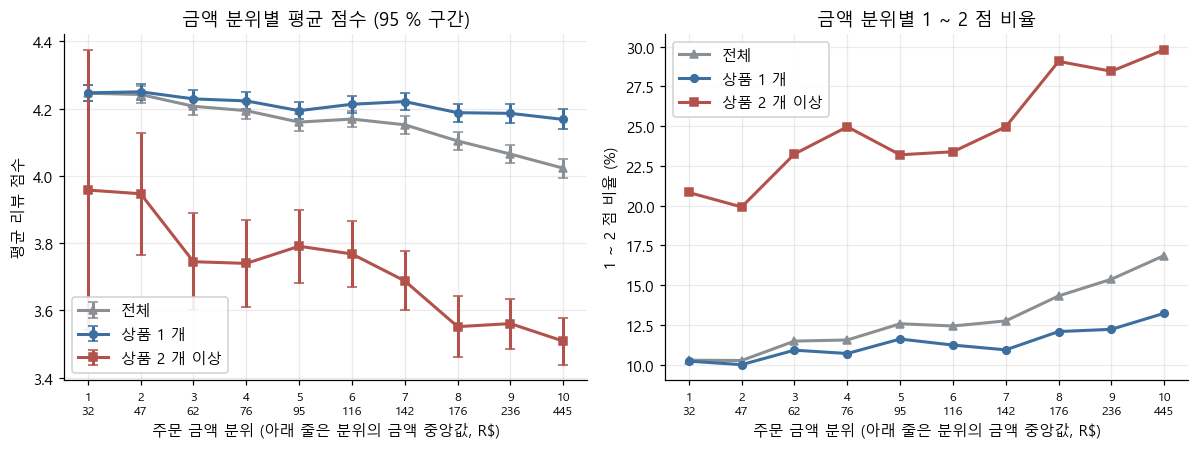

In [28]:
t = itm[itm['decile'] != '전체'].reset_index(drop=True)
x = list(range(1, len(t) + 1))
labels = [f'{i}\n{m:,.0f}' for i, m in zip(x, t['median_amount'])]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.errorbar(x, t['all_avg'], yerr=t['all_ci_half'], color=GRAY, marker='^', ms=5, lw=2,
            capsize=3, label='전체')
ax.errorbar(x, t['one_avg'], yerr=t['one_ci_half'], color=BLUE, marker='o', ms=5, lw=2,
            capsize=3, label='상품 1 개')
ax.errorbar(x, t['multi_avg'], yerr=t['multi_ci_half'], color=RED, marker='s', ms=5, lw=2,
            capsize=3, label='상품 2 개 이상')
ax.set_ylabel('평균 리뷰 점수')
ax.set_title('금액 분위별 평균 점수 (95 % 구간)')
ax.legend(loc='lower left', framealpha=0.9)

ax = axes[1]
ax.plot(x, t['all_low_pct'], color=GRAY, marker='^', ms=5, lw=2, label='전체')
ax.plot(x, t['one_low_pct'], color=BLUE, marker='o', ms=5, lw=2, label='상품 1 개')
ax.plot(x, t['multi_low_pct'], color=RED, marker='s', ms=5, lw=2, label='상품 2 개 이상')
ax.set_ylabel('1 ~ 2 점 비율 (%)')
ax.set_title('금액 분위별 1 ~ 2 점 비율')
ax.legend(loc='upper left', framealpha=0.9)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_xlabel('주문 금액 분위 (아래 줄은 분위의 금액 중앙값, R$)')
plt.tight_layout()
plt.show()

**상품이 2 개 이상인 주문은 모든 금액 분위에서 점수가 낮다.** 평균 점수가 상품 1 개 4.214, 2 개 이상 3.636 으로 0.578 차이다.
분위별로도 1 분위 4.247 대 3.958, 10 분위 4.168 대 3.509 로 열 분위 모두 낮다.
두 무리의 95 % 구간은 상품이 2 개 이상인 주문이 48 건인 1 분위에서만 겹치고 나머지 아홉 분위에서는 겹치지 않는다.
1 ~ 2 점 비율은 11.26 % 와 26.72 % 다.

**같은 상품 개수 안에서도 금액이 높을수록 점수가 낮다.** 상품 1 개는 1 분위 4.247 에서 10 분위 4.168 로 0.080,
2 개 이상은 3.958 에서 3.509 로 0.450 내려간다. 1 ~ 2 점 비율은 상품 1 개가 10.23 % 에서 13.24 %,
2 개 이상이 20.83 % 에서 29.80 % 로 오른다.

전체 주문의 선은 두 선 사이를 지나고 분위가 오를수록 아래쪽 선에 가까워진다.
분위에서 상품 2 개 이상이 차지하는 비율이 0.50 % 에서 21.91 % 로 늘기 때문이다.

두 무리의 수준 차이와 각 무리 안의 변화가 4 의 기울기에 얼마씩 들어가는지 나눈다.
5 에서 배송을 나눌 때와 같은 방식으로, 분위가 오를수록 상품 2 개 이상이 늘어나는 데서 오는 몫과
상품 개수를 고정했을 때 남는 몫으로 가른다.

- `grp` · `orders` — 상품 개수 묶음과 주문 수
- `diff_avg` — 10 분위와 1 분위의 평균 점수 차이
- `slope` · `slope_ci_low` · `slope_ci_high` — 분위가 하나 오를 때 평균 점수의 변화와 95 % 구간
- `part` · `slope_part` · `pct` — 전체 기울기에서 각 몫이 차지하는 값과 비중

In [29]:
isl=con.execute("""
WITH s AS (
    SELECT amount_decile AS d,
           CASE WHEN items = 1 THEN '1. 1 개' ELSE '2. 2 개 이상' END AS g,
           review_score
    FROM amount_review
),
long AS (
    SELECT g, d, review_score FROM s
    UNION ALL
    SELECT '3. 전체', d, review_score FROM s
),
f AS (
    SELECT g                                                             AS grp,
           COUNT(*)                                                      AS orders,
           AVG(review_score) FILTER (d = 10) - AVG(review_score) FILTER (d = 1) AS diff_avg,
           regr_slope(review_score, d)                                   AS sl,
           SQRT((regr_syy(review_score, d)
                 - POWER(regr_sxy(review_score, d), 2) / regr_sxx(review_score, d))
                / (regr_count(review_score, d) - 2)
                / regr_sxx(review_score, d))                             AS se
    FROM long
    GROUP BY g
)
SELECT grp,
       orders,
       ROUND(diff_avg, 3)       AS diff_avg,
       ROUND(sl, 4)             AS slope,
       ROUND(sl - 1.96 * se, 4) AS slope_ci_low,
       ROUND(sl + 1.96 * se, 4) AS slope_ci_high
FROM f
ORDER BY grp
""").df()

isl

,grp,orders,diff_avg,slope,slope_ci_low,slope_ci_high
0,1. 1 개,86061,-0.080,-0.0082,-0.0111,-0.0053
1,2. 2 개 이상,9499,-0.450,-0.0478,-0.0617,-0.0338
2,3. 전체,95560,-0.222,-0.0235,-0.0263,-0.0207


In [30]:
ish=con.execute("""
WITH s AS (
    SELECT amount_decile AS d,
           CASE WHEN items = 1 THEN '1. 1 개' ELSE '2. 2 개 이상' END AS g,
           review_score
    FROM amount_review
),
whole AS (
    SELECT regr_slope(review_score, d) AS sl
    FROM s
),
by_group AS (
    SELECT g,
           regr_sxx(review_score, d)   AS sxx,
           regr_slope(review_score, d) AS sl
    FROM s
    GROUP BY g
),
within AS (
    SELECT SUM(sxx * sl) / SUM(sxx) AS sl
    FROM by_group
)
SELECT '1. 상품 개수 구성'                    AS part,
       ROUND(w.sl - i.sl, 4)               AS slope_part,
       ROUND(100 * (w.sl - i.sl) / w.sl, 1) AS pct
FROM whole AS w
CROSS JOIN within AS i

UNION ALL
SELECT '2. 남는 몫',
       ROUND(i.sl, 4),
       ROUND(100 * i.sl / w.sl, 1)
FROM whole AS w
CROSS JOIN within AS i

UNION ALL
SELECT '3. 전체 기울기',
       ROUND(w.sl, 4),
       100.0
FROM whole AS w

ORDER BY part
""").df()

ish

,part,slope_part,pct
0,1. 상품 개수 구성,-0.0126,53.8
1,2. 남는 몫,-0.0109,46.2
2,3. 전체 기울기,-0.0235,100.0


**상품 개수와 금액이 각각 낮은 점수와 함께 나타난다.** 4 의 기울기 −0.0235 중 상품 개수 구성이 −0.0126(53.8 %),
상품 개수를 고정하고 남는 몫이 −0.0109(46.2 %) 다.
상품 개수 묶음 안의 기울기는 1 개 −0.0082(−0.0111 ~ −0.0053), 2 개 이상 −0.0478(−0.0617 ~ −0.0338) 으로 둘 다 0 을 포함하지 않는다.

금액이 높은 주문의 낮은 점수에는 둘이 함께 들어 있다. 금액이 오를수록 상품이 여럿인 주문이 늘고,
그 주문은 어느 금액대에서나 0.29 ~ 0.66 점 낮다. 상품 개수를 고정해도 금액이 오르면 점수가 내려가고,
그 폭은 상품 2 개 이상에서 0.450 으로 1 개의 0.080 보다 크다.

상품이 2 개 이상인 주문을 상품 구성으로 가른다. 같은 상품을 여러 개 산 주문과 다른 상품을 산 주문은 받는 물건이 다르다.
다른 상품은 다시 한 카테고리 안인지 여러 카테고리인지로 나눈다.
카테고리가 등록되지 않은 상품이 낀 주문은 어느 쪽인지 가릴 수 없으므로 따로 둔다.

- `kind` — 상품 구성. 같은 상품 / 다른 상품이면서 한 카테고리 / 카테고리 2 개 이상 / 카테고리 미등록 포함
- `orders` · `median_items` · `median_amount` — 주문 수, 상품 개수의 중앙값, 주문 금액의 중앙값
- `avg_score` · `ci_half` · `low_pct` — 평균 점수, 95 % 구간의 반폭, 1 ~ 2 점 비율

In [31]:
con.execute("""
WITH mix AS (
    SELECT i.order_id,
           COUNT(DISTINCT i.product_id)                      AS products,
           COUNT(DISTINCT p.product_category_name)           AS categories,
           COUNT(*) FILTER (p.product_category_name IS NULL) AS unregistered
    FROM order_items AS i
    JOIN products    AS p ON p.product_id = i.product_id
    GROUP BY i.order_id
),
s AS (
    SELECT CASE WHEN m.products = 1      THEN '1. 같은 상품'
                WHEN m.unregistered > 0  THEN '4. 카테고리 미등록 포함'
                WHEN m.categories = 1    THEN '2. 다른 상품 · 한 카테고리'
                ELSE                          '3. 카테고리 2 개 이상' END AS kind,
           a.items,
           a.order_amount,
           a.review_score
    FROM amount_review AS a
    JOIN mix AS m ON m.order_id = a.order_id
    WHERE a.items > 1
)
SELECT CASE WHEN GROUPING(kind) = 1 THEN '전체' ELSE kind END            AS kind,
       COUNT(*)                                                         AS orders,
       MEDIAN(items)                                                    AS median_items,
       ROUND(MEDIAN(order_amount), 2)                                   AS median_amount,
       ROUND(AVG(review_score), 3)                                      AS avg_score,
       ROUND(1.96 * STDDEV_SAMP(review_score) / SQRT(COUNT(*)), 3)      AS ci_half,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END), 2) AS low_pct
FROM s
GROUP BY GROUPING SETS ((kind), ())
ORDER BY kind
""").df()

,kind,orders,median_items,median_amount,avg_score,ci_half,low_pct
0,1. 같은 상품,6349,2.0,164.04,3.767,0.038,23.22
1,2. 다른 상품 · 한 카테고리,2371,2.0,181.33,3.471,0.067,31.08
2,3. 카테고리 2 개 이상,714,2.0,210.52,3.077,0.123,41.32
3,4. 카테고리 미등록 포함,65,2.0,136.70,3.000,0.445,49.23
4,전체,9499,2.0,172.04,3.636,0.032,26.72


**상품 구성별 평균 점수.** 상품 2 개 이상 9,499 건에서 같은 상품을 여러 개 산 주문이 6,349 건 · 3.767(±0.038),
다른 상품이지만 한 카테고리인 주문이 2,371 건 · 3.471(±0.067), 카테고리가 2 개 이상인 주문이 714 건 · 3.077(±0.123) 이다.
1 ~ 2 점 비율은 23.22 % · 31.08 % · 41.32 % 다. 상품이 1 개인 주문의 평균은 4.214 다.

상품 개수의 중앙값은 네 무리 모두 2 개이고 금액 중앙값은 164.04 · 181.33 · 210.52 다.
카테고리가 등록되지 않은 상품이 낀 주문은 65 건 · 3.000(±0.445) 으로 구간이 넓다.
이 네 무리에는 판매자가 한 곳인 주문과 여러 곳인 주문이 함께 들어 있다.

섞인 주문의 점수가 낮은 것이 그런 주문을 파는 판매자가 원래 낮기 때문인지 본다.
판매자가 하나인 주문만 쓰고, 판매자를 두 기준으로 가른다 — 카테고리가 2 개 이상인 주문을 판 적이 있는지,
취급한 카테고리가 2 개 이상인지. 각 무리를 그 판매자들의 **상품 1 개 주문**으로만 견주면
섞어 파는 일과 무관한 자리에서 판매자의 점수를 비교할 수 있다.

- `flag` · `group` — 가르는 기준과 그 무리
- `sellers` · `single_orders` — 판매자 수와 그들의 상품 1 개 주문 수
- `single_avg` · `ci_half` · `single_low_pct` — 상품 1 개 주문의 평균 점수, 95 % 구간의 반폭, 1 ~ 2 점 비율

In [32]:
mxs=con.execute("""
WITH one_seller AS (
    SELECT order_id, MIN(seller_id) AS seller_id
    FROM order_items
    GROUP BY order_id
    HAVING COUNT(DISTINCT seller_id) = 1
),
mix AS (
    SELECT i.order_id,
           COUNT(DISTINCT p.product_category_name)           AS categories,
           COUNT(*) FILTER (p.product_category_name IS NULL) AS unregistered
    FROM order_items AS i
    JOIN products    AS p ON p.product_id = i.product_id
    GROUP BY i.order_id
),
sold AS (
    SELECT os.seller_id,
           COUNT(DISTINCT p.product_category_name) AS seller_categories
    FROM one_seller  AS os
    JOIN order_items AS i ON i.order_id = os.order_id
    JOIN products    AS p ON p.product_id = i.product_id
    GROUP BY os.seller_id
),
o AS (
    SELECT os.seller_id,
           a.items,
           a.review_score,
           a.items > 1 AND m.categories > 1 AND m.unregistered = 0 AS mixed
    FROM amount_review AS a
    JOIN one_seller    AS os USING (order_id)
    JOIN mix           AS m  ON m.order_id = a.order_id
),
seller AS (
    SELECT o.seller_id,
           MAX(CASE WHEN o.mixed THEN 1 ELSE 0 END) AS sold_mixed,
           sold.seller_categories,
           COUNT(*) FILTER (o.items = 1)            AS single_orders
    FROM o
    JOIN sold USING (seller_id)
    GROUP BY o.seller_id, sold.seller_categories
),
long AS (
    SELECT '1. 카테고리 2 개 이상 주문을 판 적' AS flag,
           CASE WHEN s.sold_mixed = 1 THEN '1. 있음' ELSE '2. 없음' END AS grp,
           s.seller_id, o.review_score
    FROM seller AS s
    JOIN o USING (seller_id)
    WHERE o.items = 1

    UNION ALL
    SELECT '2. 취급한 카테고리 수',
           CASE WHEN s.seller_categories > 1 THEN '1. 2 개 이상' ELSE '2. 1 개' END,
           s.seller_id, o.review_score
    FROM seller AS s
    JOIN o USING (seller_id)
    WHERE o.items = 1
)
SELECT flag,
       grp                                                              AS "group",
       COUNT(DISTINCT seller_id)                                        AS sellers,
       COUNT(*)                                                         AS single_orders,
       ROUND(AVG(review_score), 3)                                      AS single_avg,
       ROUND(1.96 * STDDEV_SAMP(review_score) / SQRT(COUNT(*)), 3)      AS ci_half,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END), 2) AS single_low_pct
FROM long
GROUP BY flag, grp
ORDER BY flag, grp
""").df()

mxs

,flag,group,sellers,single_orders,single_avg,ci_half,single_low_pct
0,1. 카테고리 2 개 이상 주문을 판 적,1. 있음,68,19940,4.197,0.017,11.30
1,1. 카테고리 2 개 이상 주문을 판 적,2. 없음,2792,66121,4.219,0.009,11.25
2,2. 취급한 카테고리 수,1. 2 개 이상,1274,68752,4.209,0.009,11.28
3,2. 취급한 카테고리 수,2. 1 개,1586,17309,4.232,0.018,11.20


**카테고리를 섞어 판 적 있는 판매자가 원래 낮지는 않다.** 카테고리 2 개 이상인 주문을 판 적 있는 판매자는 69 곳이고, 그중 한 곳은 상품 1 개 주문이 없어 이 비교에서 빠진다.
나머지 68 곳의 상품 1 개 주문 19,940 건의 평균이 4.197(±0.017) 이다. 그런 주문이 없는 2,792 곳의 66,121 건은 4.219(±0.009) 로
차이가 0.022 다. 1 ~ 2 점 비율은 11.30 % 와 11.25 % 다.

취급한 카테고리 수로 갈라도 같다. 2 개 이상인 1,274 곳이 4.209(±0.009), 1 개인 1,586 곳이 4.232(±0.018) 다.

카테고리 2 개 이상인 주문을 판 적 있는 69 곳만 남겨, 그 판매자들의 주문을 구성별로 견준다.
판매자 범위만 좁힐 뿐 구성별로 주문을 모아 평균 내므로, 무리마다 판매자 구성이 달라 판매자 사이의 차이는 남는다.

In [33]:
con.execute("""
WITH one_seller AS (
    SELECT order_id, MIN(seller_id) AS seller_id
    FROM order_items
    GROUP BY order_id
    HAVING COUNT(DISTINCT seller_id) = 1
),
mix AS (
    SELECT i.order_id,
           COUNT(DISTINCT i.product_id)                      AS products,
           COUNT(DISTINCT p.product_category_name)           AS categories,
           COUNT(*) FILTER (p.product_category_name IS NULL) AS unregistered
    FROM order_items AS i
    JOIN products    AS p ON p.product_id = i.product_id
    GROUP BY i.order_id
),
o AS (
    SELECT os.seller_id,
           a.review_score,
           CASE WHEN a.items = 1        THEN '1. 상품 1 개'
                WHEN m.products = 1     THEN '2. 같은 상품'
                WHEN m.unregistered > 0 THEN '5. 카테고리 미등록 포함'
                WHEN m.categories = 1   THEN '3. 다른 상품 · 한 카테고리'
                ELSE                         '4. 카테고리 2 개 이상' END AS kind,
           a.items > 1 AND m.categories > 1 AND m.unregistered = 0     AS mixed
    FROM amount_review AS a
    JOIN one_seller    AS os USING (order_id)
    JOIN mix           AS m  ON m.order_id = a.order_id
),
picked AS (
    SELECT seller_id
    FROM o
    GROUP BY seller_id
    HAVING MAX(CASE WHEN mixed THEN 1 ELSE 0 END) = 1
)
SELECT kind,
       COUNT(DISTINCT seller_id)                                        AS sellers,
       COUNT(*)                                                         AS orders,
       ROUND(AVG(review_score), 3)                                      AS avg_score,
       ROUND(1.96 * STDDEV_SAMP(review_score) / SQRT(COUNT(*)), 3)      AS ci_half,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END), 2) AS low_pct
FROM o
JOIN picked USING (seller_id)
GROUP BY kind
ORDER BY kind
""").df()

,kind,sellers,orders,avg_score,ci_half,low_pct
0,1. 상품 1 개,68,19940,4.197,0.017,11.30
1,2. 같은 상품,59,1669,3.695,0.075,24.33
2,3. 다른 상품 · 한 카테고리,45,561,3.652,0.134,26.74
3,4. 카테고리 2 개 이상,69,152,3.783,0.243,23.03
4,5. 카테고리 미등록 포함,1,3,5.000,0.000,0.00


**69 곳의 주문에서는 구성에 따른 차이를 확인하지 못했다.** 상품 1 개가 19,940 건 · 4.197(±0.017),
같은 상품이 1,669 건 · 3.695(±0.075), 다른 상품 한 카테고리가 561 건 · 3.652(±0.134),
카테고리 2 개 이상이 152 건 · 3.783(±0.243) 이다. 상품이 2 개 이상인 세 무리의 구간은 서로 겹친다.
무리마다 판매자가 68 · 59 · 45 · 69 곳으로 달라, 이 비교는 판매자 사이의 차이를 걸러내지 않는다.

상품 구성과 판매자 수를 함께 가른다. 상품이 2 개 이상인 주문은 판매자가 여럿일 수 있고,
그때는 배송이 판매자마다 따로 이루어진다. 두 가지가 겹쳐 있으므로 나눠서 센다.

- `kind` · `sellers_in_order` — 상품 구성과 그 주문의 판매자 수
- `orders` · `avg_score` · `ci_half` · `low_pct` — 주문 수, 평균 점수, 95 % 구간의 반폭, 1 ~ 2 점 비율

In [34]:
con.execute("""
WITH mix AS (
    SELECT i.order_id,
           COUNT(DISTINCT i.product_id)                      AS products,
           COUNT(DISTINCT i.seller_id)                       AS sellers,
           COUNT(DISTINCT p.product_category_name)           AS categories,
           COUNT(*) FILTER (p.product_category_name IS NULL) AS unregistered
    FROM order_items AS i
    JOIN products    AS p ON p.product_id = i.product_id
    GROUP BY i.order_id
)
SELECT CASE WHEN m.products = 1      THEN '1. 같은 상품'
            WHEN m.unregistered > 0  THEN '4. 카테고리 미등록 포함'
            WHEN m.categories = 1    THEN '2. 다른 상품 · 한 카테고리'
            ELSE                          '3. 카테고리 2 개 이상' END AS kind,
       CASE WHEN m.sellers = 1 THEN '1. 판매자 1 곳'
            ELSE                    '2. 판매자 2 곳 이상' END        AS sellers_in_order,
       COUNT(*)                                                     AS orders,
       ROUND(AVG(a.review_score), 3)                                AS avg_score,
       ROUND(1.96 * STDDEV_SAMP(a.review_score) / SQRT(COUNT(*)), 3) AS ci_half,
       ROUND(100.0 * AVG(CASE WHEN a.review_score <= 2 THEN 1.0 ELSE 0.0 END), 2) AS low_pct
FROM amount_review AS a
JOIN mix AS m ON m.order_id = a.order_id
WHERE a.items > 1
GROUP BY kind, sellers_in_order
ORDER BY kind, sellers_in_order
""").df()

,kind,sellers_in_order,orders,avg_score,ci_half,low_pct
0,1. 같은 상품,1. 판매자 1 곳,6349,3.767,0.038,23.22
1,2. 다른 상품 · 한 카테고리,1. 판매자 1 곳,1706,3.708,0.075,24.85
2,2. 다른 상품 · 한 카테고리,2. 판매자 2 곳 이상,665,2.863,0.127,47.07
3,3. 카테고리 2 개 이상,1. 판매자 1 곳,152,3.783,0.243,23.03
4,3. 카테고리 2 개 이상,2. 판매자 2 곳 이상,562,2.886,0.138,46.26
5,4. 카테고리 미등록 포함,1. 판매자 1 곳,34,3.559,0.586,35.29
6,4. 카테고리 미등록 포함,2. 판매자 2 곳 이상,31,2.387,0.614,64.52


**상품 구성별 점수 차이는 구성이 아니라 한 주문의 판매자 수에서 온다.** 판매자가 한 곳인 주문은
같은 상품 6,349 건 · 3.767(±0.038), 다른 상품 한 카테고리 1,706 건 · 3.708(±0.075),
카테고리 2 개 이상 152 건 · 3.783(±0.243) 으로 세 구간이 겹친다.
판매자가 두 곳 이상인 주문은 다른 상품 한 카테고리 665 건 · 2.863(±0.127), 카테고리 2 개 이상 562 건 · 2.886(±0.138) 이다.
1 ~ 2 점 비율도 24.85 % · 23.03 % 에서 47.07 % · 46.26 % 로 오른다.

앞 표에서 카테고리 2 개 이상이 3.077 이던 것은 그 714 건 가운데 562 건이 판매자 두 곳 이상인 주문이기 때문이다.

판매자가 두 곳 이상인 주문의 낮은 점수가 배송에서 오는지 본다. 상품이 2 개 이상인 주문을 판매자 수로 가르고
5 와 같은 값들을 구한다. 도착일은 주문 단위로 하나뿐이다. 판매자가 여럿이면 상품이 따로 도착하는데,
기록된 도착일이 그중 어느 시점인지는 데이터에 없다.

- `orders` · `median_items` — 주문 수와 상품 개수의 중앙값
- `late_pct` · `median_days` — 약속 위반율과 배송 소요일의 중앙값
- `avg_score` — 평균 점수
- `kept_orders` · `avg_kept` · `ci_kept` — 약속을 지킨 주문의 수, 평균 점수, 95 % 구간의 반폭
- `avg_late` — 약속을 어긴 주문의 평균 점수

In [35]:
con.execute("""
WITH mix AS (
    SELECT i.order_id,
           COUNT(DISTINCT i.seller_id) AS sellers
    FROM order_items AS i
    GROUP BY i.order_id
)
SELECT CASE WHEN m.sellers = 1 THEN '1. 판매자 1 곳'
            ELSE                    '2. 판매자 2 곳 이상' END                    AS sellers_in_order,
       COUNT(*)                                                                 AS orders,
       MEDIAN(a.items)                                                          AS median_items,
       ROUND(100.0 * AVG(CASE WHEN a.days_vs_promise > 0 THEN 1.0 ELSE 0.0 END), 2) AS late_pct,
       MEDIAN(a.delivery_days)                                                  AS median_days,
       ROUND(AVG(a.review_score), 3)                                            AS avg_score,
       COUNT(*) FILTER (a.days_vs_promise <= 0)                                 AS kept_orders,
       ROUND(AVG(a.review_score) FILTER (a.days_vs_promise <= 0), 3)            AS avg_kept,
       ROUND(1.96 * STDDEV_SAMP(a.review_score) FILTER (a.days_vs_promise <= 0)
             / SQRT(COUNT(*) FILTER (a.days_vs_promise <= 0)), 3)               AS ci_kept,
       ROUND(AVG(a.review_score) FILTER (a.days_vs_promise > 0), 3)             AS avg_late
FROM amount_review AS a
JOIN mix AS m ON m.order_id = a.order_id
WHERE a.items > 1
GROUP BY sellers_in_order
ORDER BY sellers_in_order
""").df()

,sellers_in_order,orders,median_items,late_pct,median_days,avg_score,kept_orders,avg_kept,ci_kept,avg_late
0,1. 판매자 1 곳,8241,2.0,5.81,10.0,3.754,7762,3.852,0.033,2.167
1,2. 판매자 2 곳 이상,1258,2.0,0.95,8.0,2.862,1246,2.872,0.093,1.833


**판매자가 두 곳 이상인 주문의 낮은 점수는 약속 위반율로는 잡히지 않는다.** 약속 위반율이 0.95 % 로
판매자가 한 곳인 주문의 5.81 % 보다 낮고 소요일 중앙값도 8 일과 10 일이다. 상품 개수의 중앙값은 양쪽 모두 2 개다.
그런데도 평균 점수는 2.862 와 3.754 다.

약속을 지킨 주문만 보아도 2.872(±0.093) 과 3.852(±0.033) 로 0.980 차이가 남는다.
약속을 어긴 주문의 평균은 1.833 과 2.167 이고, 판매자 두 곳 이상에서 약속을 어긴 주문은 12 건이다.

따로 발송되는 주문인데 소요일이 더 짧고 위반율이 더 낮다. 도착일이 마지막 상품이 아니라 먼저 도착한 상품의 시점에
기록되었다면 이 모양이 나온다. 그 경우 고객은 일부만 받은 상태에서 리뷰를 남겼을 수 있고, 낮은 점수가 나머지 상품의
지연이나 누락에서 왔을 수 있다. 이 데이터로는 두 경우를 가르지 못한다.

**조건 4 의 결과.** 같은 금액대에서 상품 개수는 점수를 가른다. 상품 1 개 4.214, 2 개 이상 3.636 이고 열 분위 모두에서 낮다.

판매자 수를 고정하면 상품 구성에 따른 차이는 확인하지 못했다. 판매자가 한 곳인 주문 안에서
같은 상품 3.767(±0.038) 과 다른 상품 한 카테고리 3.708(±0.075) 는 구간이 겹치고,
카테고리 2 개 이상은 152 건이라 구간이 ±0.243 으로 넓어 그보다 작은 차이는 가를 수 없다.

한 주문의 판매자가 두 곳 이상이면 2.863 · 2.886 으로 0.9 점가량 내려간다. 그 차이는 약속 위반율로는 잡히지 않는다.
판매자가 두 곳 이상인 주문은 약속 위반율이 0.95 % 로 더 낮은데도 약속을 지킨 주문만의 평균이 2.872 로
판매자 한 곳의 3.852 보다 0.980 낮다. 기록된 도착일이 어느 상품의 도착 시점인지는 데이터에 없어 두 경우를 가르지 못한다.

카테고리를 여럿 파는 판매자가 원래 낮은 것도 아니다. 그 판매자들의 상품 1 개 주문은 4.197 로 나머지 4.219 와 0.022 차이다.

**판매자를 점수로 평가할 때 주문의 금액대와 상품 개수를 함께 맞춰야 한다.**
금액 분위가 오를수록 점수가 내려가고(상품 개수를 고정해도 분위당 −0.0109), 상품이 2 개 이상이면 같은 분위에서 0.29 ~ 0.66 낮다.
둘이 판매자마다 다른 비율로 섞여 있어, 점수를 그대로 견주면 고액 · 상품 개수가 많은 주문을 많이 받은 쪽이 그만큼 낮게 읽힌다.
07 의 판매자 판정은 판매자가 한 곳인 주문만 쓰므로 판매자 수는 이미 빠져 있다.

## 8. 정리

### 가설의 판정

**조건 1 — 주문 금액이 높을수록 리뷰 점수가 낮다.** 그렇다.

금액 10 분위의 평균 점수가 1 분위 4.246 에서 10 분위 4.023 으로 대체로 한 방향으로 내려가고,
차이 −0.222 의 95 % 구간 −0.260 ~ −0.185 가 0 을 포함하지 않는다. 10 개 분위를 모두 쓴 기울기는
분위당 −0.0235(−0.0263 ~ −0.0207) 이다. 1 ~ 2 점 비율은 10.29 % 에서 16.87 % 로 오른다.

**조건 2 — 그 차이 중 배송에서 오는 몫은 45.8 % 다.**

전체 기울기 −0.0235 중 배송이 설명하는 몫이 −0.0107(45.8 %), 남는 몫이 −0.0127(54.2 %) 다.
배송 몫은 약속 위반 구성 −0.0051(21.9 %) 과 소요일 구성 −0.0056(23.9 %) 으로 갈린다.

금액이 높은 분위일수록 약속 위반율이 높고(5.36 % → 7.91 %) 소요일 중앙값도 길다(8 일 → 11 일).
소요일의 영향을 제외해도 0 ~ 7 일 −0.0116, 8 ~ 14 일 −0.0119, 15 ~ 21 일 −0.0140, 22 ~ 30 일 −0.0208 로
네 구간 모두 95 % 구간이 0 을 포함하지 않는다.

운임으로 나눈 10 분위에서는 격차가 더 크다. 평균 점수가 4.344 에서 3.875 로 −0.469 이고
소요일 중앙값이 5 일에서 13 일로 벌어진다.

판매자가 여럿인 주문 1,258 건은 기록된 도착일이 어느 상품의 시점인지 알 수 없는데, 이 분해에 그대로 들어 있다.
표본의 1.3 % 다.

**조건 3 — 그 차이 중 카테고리 구성에서 오는 몫은 보이지 않는다.**

주문 500 건 이상인 카테고리의 같은 주문에서 전체 금액 분위의 기울기가 −0.0202, 카테고리 안에서 다시 나눈 분위의 기울기가
−0.0217 로 카테고리 가격대를 걷어내도 기울기가 줄지 않는다.

카테고리 사이에서는 금액 중앙값과 평균 점수의 상관계수가 −0.311 이나 95 % 구간이 −0.629 ~ 0.096 으로 0 을 포함한다.
카테고리 안의 평균 점수는 4.259 에서 4.032 로 −0.227 이고, 카테고리별로는 25 개 중 22 개에서
상위 20 % 가 하위 20 % 보다 낮으며 그중 14 개(주문 65,669 건)는 차이의 구간이 0 을 포함하지 않는다.

**조건 4 — 같은 금액대에서 상품 개수는 점수를 가르고, 상품 구성에 따른 차이는 확인하지 못했다.**

전체 기울기 −0.0235 중 상품 개수 구성이 −0.0126(53.8 %), 상품 개수를 고정하고 남는 몫이 −0.0109(46.2 %) 다.
상품 1 개 주문의 평균이 4.214, 2 개 이상이 3.636 이고 열 분위 모두에서 낮다. 두 무리의 격차는 같은 분위에서 0.29 ~ 0.66 이다.
상품 개수 묶음 안의 기울기는 1 개 −0.0082(−0.0111 ~ −0.0053), 2 개 이상 −0.0478(−0.0617 ~ −0.0338) 이다.

판매자 수를 고정하면 상품 구성에 따른 차이는 확인하지 못했다. 판매자가 한 곳인 주문 안에서
같은 상품 3.767(±0.038) 과 다른 상품 한 카테고리 3.708(±0.075) 는 구간이 겹치고,
카테고리 2 개 이상은 152 건이라 구간이 ±0.243 으로 넓어 그보다 작은 차이는 가를 수 없다.
카테고리 2 개 이상인 주문을 판 적 있는 판매자 68 곳의 상품 1 개 주문 평균도 4.197 로, 그런 주문이 없는 2,792 곳의 4.219 와 0.022 차이다.

갈리는 것은 한 주문의 판매자 수다. 상품이 2 개 이상인 주문에서 판매자가 두 곳 이상이면 평균이 2.862,
한 곳이면 3.754 다. 그 차이는 약속 위반율로는 잡히지 않는다. 판매자가 두 곳 이상인 주문은 약속 위반율이 0.95 % 로
한 곳인 주문의 5.81 % 보다 낮고 소요일 중앙값도 8 일과 10 일인데, 약속을 지킨 주문만 보아도
2.872(±0.093) 과 3.852(±0.033) 로 0.980 차이가 남는다.
기록된 도착일이 어느 상품의 도착 시점인지는 데이터에 없어 두 경우를 가르지 못한다.

조건 2 와 조건 4 의 분해는 각각 전체 기울기를 기준으로 구한 값이라 두 몫을 더할 수 없다.
배송 분해는 상품 개수가 섞인 표본에서 구했다.

### 제안

**점수로 판매자를 평가할 때는 약속을 어긴 주문을 뺀 뒤 카테고리 · 주문 총액 · 상품 개수를 맞춰 견준다.**

약속을 어긴 주문은 배송에서 온 낮은 점수이고 06 · 07 의 예상 도착일 처방이 다루는 자리다. 남은 리뷰를 세 가지가 같은 주문끼리 견준다.

- 카테고리 — 카테고리마다 평균이 다르다. 주문 500 건 이상인 25 개 중 office_furniture 가 3.668 로 가장 낮다
- 주문 총액 — 약속을 지킨 주문만 보아도 금액 분위의 기준선이 4.347 에서 4.179 까지 다르다
- 상품 개수 — 같은 금액 분위에서 상품 2 개 이상이 0.29 ~ 0.66 낮다.
  상품 하나당 불량률이 같아도 여러 개를 사면 그중 하나라도 불량일 확률이 커지므로, 상품 개수를 맞추는 것은
  판매자의 잘못을 지우는 것이 아니라 노출량을 맞추는 것이다

상품 구성은 나누지 않는다. 판매자 수를 고정하면 같은 상품과 다른 상품 한 카테고리의 구간이 겹치고,
카테고리 2 개 이상은 152 건이라 ±0.243 보다 작은 차이를 가를 수 없어 나눌 근거가 없다.

세 가지가 판매자마다 다른 비율로 섞여 있어, 점수를 그대로 견주면 고액 · 상품 개수가 많은 주문을 많이 받은 쪽이 그만큼 낮게 읽힌다.
07 의 판매자 판정은 판매자가 한 곳인 주문만 쓰므로 판매자 수는 이미 빠져 있다.
내보내는 파일에 이 값들을 모두 담았다.

**여러 판매자의 상품을 한 번에 산 주문은 따로 들여다본다.** 상품이 2 개 이상인 주문에서 판매자가 두 곳 이상이면
약속을 지킨 주문만 보아도 판매자 한 곳보다 0.980 낮다. 어느 판매자에게도 귀속되지 않는 주문이라 판매자 평가로는
다룰 수 없고, 주문이 판매자별로 나뉘어 도착하는 과정에서 무엇이 일어나는지부터 확인해야 한다.

**배송 쪽 개입만으로는 절반도 줄지 않는다.**
전체 기울기 중 배송이 설명하는 몫은 45.8 % 이고, 그중 예상 도착일로 다룰 수 있는 약속 위반 구성은 21.9 % 다.

### 이 분석이 답하지 못하는 것

**운임과 주문 금액 중 어느 쪽이 얼마나 움직이는가.** 확인하지 않음.
둘의 상관이 0.491 이고 운임 분위를 따라 주문 금액도 함께 오른다.

**금액 상위 주문에서 무엇이 낮은 평가를 만드는가.** 확인하지 않음.
상품 정보량(사진 수 · 설명 길이)과 무게는 이 노트북에서 다루지 않았다.

**판매자가 둘 이상인 주문에서 무엇이 점수를 낮추는가.** 확인하지 않음.
도착일이 주문 단위로 하나뿐이라 상품이 따로 닿은 간격은 다루지 않았다.
기록된 도착일이 첫 상품의 도착 시점일 가능성이 있고, 그렇다면 약속 위반율과 소요일이 이 주문들의 배송을 제대로 나타내지 못한다.

**판매자가 한 곳인 주문에서 상품이 2 개 이상이면 왜 낮은가.** 확인하지 않음.
판매자가 한 곳이어도 상품 2 개 이상은 3.754 로 상품 1 개의 4.214 보다 0.46 낮다. 제안은 이 차이가 노출량에서 온다고 보고 상품 개수를 맞추지만,
그것이 맞는지는 이 노트북에서 확인하지 않았다.

## 9. 내보내기

Tableau 에서 별도 드라이버 설정 없이 바로 열 수 있도록 주문 단위 한 장을 파일로 뽑는다.
주문 금액과 그 구성, 금액 10 분위, 카테고리와 카테고리 안의 금액 10 분위(주문 500 건 이상 카테고리만),
상품 개수와 상품 구성, 주문의 판매자 수, 약속 대비 값과 리뷰 점수를 담아 4 ~ 7 의 표와 그림을 파일 하나에서 다시 만들 수 있게 한다.

- `sellers` — 그 주문의 판매자 수
- `kind` — 상품 구성. 상품 1 개 / 같은 상품 / 다른 상품이면서 한 카테고리 / 카테고리 2 개 이상 / 카테고리 미등록 포함
- `kept` — 약속을 지킨 주문인지

내보낸 파일을 다시 읽어 행 수와 금액 분위별 주문 수 · 평균 점수 · 1 ~ 2 점 비율을 4 의 출력과 대조하고,
상품 1 개와 2 개 이상의 평균, 판매자가 두 곳 이상인 주문의 비율을 7 의 출력과 대조한다.

기울기 · 분해 · 운임 분위처럼 주문 단위 파일에서 계산식을 다시 짜야 하거나 다시 만들 수 없는 결과표는
분석 셀의 결과를 그대로 파일로 뽑는다.

- `08_slope.csv` — 4 의 1 분위와 10 분위의 차이, 분위당 기울기와 각각의 95 % 구간
- `08_slope_days.csv` — 5 의 소요일 구간별 기울기와 95 % 구간. `min_decile_n` 은 그 구간에서 주문이 가장 적은 분위의 주문 수
- `08_delivery_share.csv` — 5 의 배송 몫 분해. `part` 몫의 이름, `slope_part` 기울기 중 그 몫, `pct` 전체 기울기 대비 비율
- `08_freight_decile.csv` — 5 의 운임 10 분위별 운임 · 주문 금액 · 소요일의 중앙값과 약속 위반율 · 평균 점수
- `08_category_corr.csv` — 6 의 카테고리 사이 금액 중앙값과 평균 점수의 상관계수와 95 % 구간
- `08_slope_category.csv` — 6 의 전체 금액 분위와 카테고리 안 분위의 기울기
- `08_slope_items.csv` — 7 의 상품 개수 묶음별 기울기
- `08_items_share.csv` — 7 의 상품 개수 몫 분해. 컬럼은 `08_delivery_share.csv` 와 같다
- `08_mixed_seller.csv` — 7 의 카테고리 2 개 이상 주문을 판 적 있는 판매자와 없는 판매자의 상품 1 개 주문 평균.
  판매자가 여럿인 주문은 판매자가 하나로 정해지지 않아 주문 단위 파일에는 `seller_id` 를 담지 않는다

파일마다 다시 읽어 해당 절의 출력과 대조한다.

In [36]:
import os

os.makedirs('../exports', exist_ok=True)

con.execute("""
COPY (
    WITH big AS (
        SELECT category
        FROM amount_review
        WHERE category IS NOT NULL
        GROUP BY category
        HAVING COUNT(*) >= 500
    ),
    q AS (
        SELECT a.order_id,
               NTILE(10) OVER (PARTITION BY a.category ORDER BY a.order_amount, a.order_id) AS category_decile
        FROM amount_review AS a
        JOIN big USING (category)
    ),
    mix AS (
        SELECT i.order_id,
               COUNT(DISTINCT i.seller_id)                       AS sellers,
               COUNT(DISTINCT p.product_category_name)           AS categories,
               COUNT(*) FILTER (p.product_category_name IS NULL) AS unregistered
        FROM order_items AS i
        JOIN products    AS p ON p.product_id = i.product_id
        GROUP BY i.order_id
    )
    SELECT a.order_id,
           a.customer_state,
           CAST(a.order_purchase_timestamp AS DATE) AS purchase_date,
           a.items,
           a.products,
           m.sellers,
           CASE WHEN a.items = 1        THEN '1. 상품 1 개'
                WHEN a.products = 1     THEN '2. 같은 상품'
                WHEN m.unregistered > 0 THEN '5. 카테고리 미등록 포함'
                WHEN m.categories = 1   THEN '3. 다른 상품 · 한 카테고리'
                ELSE                         '4. 카테고리 2 개 이상' END AS kind,
           ROUND(a.price_sum, 2)                    AS price_sum,
           ROUND(a.freight_sum, 2)                  AS freight_sum,
           ROUND(a.order_amount, 2)                 AS order_amount,
           a.amount_decile,
           a.category,
           q.category_decile,
           a.delivery_days,
           a.days_vs_promise,
           a.days_vs_promise <= 0                   AS kept,
           a.review_score
    FROM amount_review AS a
    LEFT JOIN q   ON q.order_id = a.order_id
    JOIN      mix AS m ON m.order_id = a.order_id
    ORDER BY a.order_amount, a.order_id
) TO '../exports/08_amount_review.csv' (HEADER, DELIMITER ',')
""")

rows = con.execute(
    "SELECT COUNT(*) FROM read_csv_auto('../exports/08_amount_review.csv')").fetchone()[0]
print(f'../exports/08_amount_review.csv — {rows:,} 행')

con.execute("""
WITH f AS (SELECT * FROM read_csv_auto('../exports/08_amount_review.csv'))
SELECT LPAD(CAST(amount_decile AS VARCHAR), 2, '0')                             AS decile,
       COUNT(*)                                                                 AS orders,
       ROUND(AVG(review_score), 3)                                              AS avg_score,
       ROUND(100.0 * AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END), 2) AS low_pct,
       ROUND(AVG(review_score) FILTER (items = 1), 3)                           AS one_avg,
       ROUND(AVG(review_score) FILTER (items > 1), 3)                           AS multi_avg,
       ROUND(100.0 * AVG(CASE WHEN sellers > 1 THEN 1.0 ELSE 0.0 END), 2)       AS multi_seller_pct
FROM f
GROUP BY amount_decile
ORDER BY decile
""").df()

../exports/08_amount_review.csv — 95,560 행


,decile,orders,avg_score,low_pct,one_avg,multi_avg,multi_seller_pct
0,01,9556,4.246,10.29,4.247,3.958,0.01
1,02,9556,4.242,10.27,4.250,3.947,0.12
2,03,9556,4.207,11.49,4.229,3.745,0.28
3,04,9556,4.194,11.56,4.223,3.740,0.55
4,05,9556,4.160,12.58,4.194,3.791,0.76
5,06,9556,4.169,12.44,4.213,3.768,1.20
6,07,9556,4.152,12.76,4.221,3.688,1.59
7,08,9556,4.104,14.33,4.188,3.552,2.00
8,09,9556,4.065,15.38,4.186,3.561,3.53
9,10,9556,4.023,16.87,4.168,3.509,3.12


In [37]:
con.execute("""
COPY (SELECT * FROM slp)
TO '../exports/08_slope.csv' (HEADER, DELIMITER ',')
""")

con.execute("SELECT * FROM read_csv_auto('../exports/08_slope.csv')").df()

,diff_avg,diff_ci_low,diff_ci_high,diff_low_pp,diff_low_ci_half,slope,slope_ci_low,slope_ci_high
0,-0.222,-0.26,-0.185,6.58,0.97,-0.0235,-0.0263,-0.0207


In [38]:
con.execute("""
COPY (SELECT * FROM bnd)
TO '../exports/08_slope_days.csv' (HEADER, DELIMITER ',')
""")

con.execute("SELECT * FROM read_csv_auto('../exports/08_slope_days.csv')").df()

,band,orders,avg_score,min_decile_n,slope,slope_ci_low,slope_ci_high
0,1. 0 ~ 7 일,30442,4.413,2428,-0.0116,-0.0157,-0.0075
1,2. 8 ~ 14 일,37361,4.308,3247,-0.0119,-0.0159,-0.0078
2,3. 15 ~ 21 일,15414,4.161,1030,-0.0140,-0.0209,-0.0072
3,4. 22 ~ 30 일,5171,3.940,261,-0.0208,-0.0335,-0.0081
4,5. 31 일 이상,794,3.628,24,-0.0247,-0.0620,0.0127


In [39]:
con.execute("""
COPY (SELECT * FROM dsh)
TO '../exports/08_delivery_share.csv' (HEADER, DELIMITER ',')
""")

con.execute("SELECT * FROM read_csv_auto('../exports/08_delivery_share.csv')").df()

,part,slope_part,pct
0,1. 약속 위반 구성,-0.0051,21.9
1,2. 소요일 구성,-0.0056,23.9
2,3. 남는 몫,-0.0127,54.2
3,4. 전체 기울기,-0.0235,100.0


In [40]:
con.execute("""
COPY (SELECT * FROM frt)
TO '../exports/08_freight_decile.csv' (HEADER, DELIMITER ',')
""")

con.execute("SELECT * FROM read_csv_auto('../exports/08_freight_decile.csv')").df()

,freight_decile,orders,median_freight,median_amount,median_days,late_pct,avg_score
0,01,9556,7.87,48.78,5.0,4.21,4.344
1,02,9556,11.85,69.73,7.0,4.61,4.283
2,03,9556,13.83,80.65,9.0,5.14,4.264
3,04,9556,15.11,68.12,11.0,6.73,4.192
4,05,9556,16.34,102.03,12.0,7.45,4.181
5,06,9556,17.99,91.16,12.0,7.52,4.174
6,07,9556,19.75,135.00,12.0,7.64,4.186
7,08,9556,23.99,133.21,12.0,7.45,4.137
8,09,9556,33.08,161.08,13.0,7.65,3.924
9,10,9556,54.70,261.93,13.0,8.34,3.875


In [41]:
con.execute("""
COPY (SELECT * FROM cor)
TO '../exports/08_category_corr.csv' (HEADER, DELIMITER ',')
""")

con.execute("SELECT * FROM read_csv_auto('../exports/08_category_corr.csv')").df()

,categories,corr_amount_score,ci_low,ci_high,corr_log_amount_score,log_ci_low,log_ci_high
0,25,-0.311,-0.629,0.096,-0.137,-0.505,0.273


In [42]:
con.execute("""
COPY (SELECT * FROM csl)
TO '../exports/08_slope_category.csv' (HEADER, DELIMITER ',')
""")

con.execute("SELECT * FROM read_csv_auto('../exports/08_slope_category.csv')").df()

,scale,orders,diff_avg,slope,slope_ci_low,slope_ci_high
0,1. 전체 금액 분위,86314,-0.206,-0.0202,-0.0232,-0.0173
1,2. 카테고리 안 분위,86314,-0.227,-0.0217,-0.0246,-0.0187


In [43]:
con.execute("""
COPY (SELECT * FROM isl)
TO '../exports/08_slope_items.csv' (HEADER, DELIMITER ',')
""")

con.execute("SELECT * FROM read_csv_auto('../exports/08_slope_items.csv')").df()

,grp,orders,diff_avg,slope,slope_ci_low,slope_ci_high
0,1. 1 개,86061,-0.080,-0.0082,-0.0111,-0.0053
1,2. 2 개 이상,9499,-0.450,-0.0478,-0.0617,-0.0338
2,3. 전체,95560,-0.222,-0.0235,-0.0263,-0.0207


In [44]:
con.execute("""
COPY (SELECT * FROM ish)
TO '../exports/08_items_share.csv' (HEADER, DELIMITER ',')
""")

con.execute("SELECT * FROM read_csv_auto('../exports/08_items_share.csv')").df()

,part,slope_part,pct
0,1. 상품 개수 구성,-0.0126,53.8
1,2. 남는 몫,-0.0109,46.2
2,3. 전체 기울기,-0.0235,100.0


In [45]:
con.execute("""
COPY (SELECT * FROM mxs)
TO '../exports/08_mixed_seller.csv' (HEADER, DELIMITER ',')
""")

con.execute("SELECT * FROM read_csv_auto('../exports/08_mixed_seller.csv')").df()

,flag,group,sellers,single_orders,single_avg,ci_half,single_low_pct
0,1. 카테고리 2 개 이상 주문을 판 적,1. 있음,68,19940,4.197,0.017,11.30
1,1. 카테고리 2 개 이상 주문을 판 적,2. 없음,2792,66121,4.219,0.009,11.25
2,2. 취급한 카테고리 수,1. 2 개 이상,1274,68752,4.209,0.009,11.28
3,2. 취급한 카테고리 수,2. 1 개,1586,17309,4.232,0.018,11.20


## 10. 연결 종료

DuckDB 파일은 한 프로세스만 쓰기 모드로 열 수 있으므로 다음 노트북을 위해 여기서 종료.
뷰 `amount_review` 는 DB 파일에 저장되어 연결을 닫아도 유지.

In [46]:
con.close()